# Analysis of Blend Methods on DRAEM Performance

This notebook analyzes the influence of different `blend_method` values on evaluation metrics:
- Image-level AUROC and AP
- Pixel-level AUROC and AP

Data is fetched from Weights & Biases runs and analyzed across different object classes.

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Fetch Data from W&B

In [2]:
# Initialize W&B API
api = wandb.Api()

# Fetch runs from the project
entity = "team-cr"
project = "DRAEM_seminar_AD"

print(f"Fetching runs from {entity}/{project}...")
runs = api.runs(f"{entity}/{project}")

print(f"Total runs found: {len(runs)}")

metrics = [
        'eval/auroc_image',
        'eval/ap_image',
        'eval/auroc_pixel',
        'eval/ap_pixel'
    ]


Fetching runs from team-cr/DRAEM_seminar_AD...
Total runs found: 781


## 2. Extract Relevant Metrics

In [3]:
# Extract data from runs
data = []
from tqdm import tqdm

for run in tqdm(runs, desc="Processing runs"):
    # Check if run has blend_method in config")
    if 'blend_method' not in list(run.config.keys()):
        continue
    
    if 'blending_methods' not in run.tags:
        continue
    
    blend_method = run.config.get('blend_method', None)
    obj_name = run.config.get('obj_name', None)
    
    if blend_method is None or obj_name is None:
        continue
    
    # Get the final metrics (last epoch)
    history = run.history()
    
    if len(history) == 0:
        continue
    
    # Get metrics of interest
    metrics_to_extract = metrics    
    # Get last valid values for each metric
    run_data = {
        'run_id': run.id,
        'run_name': run.name,
        'blend_method': blend_method,
        'obj_name': obj_name,
        'state': run.state,
    }
    
    for metric in metrics_to_extract:
        if metric in history.columns:
            # Get last non-NaN value
            valid_values = history[metric].dropna()
            if len(valid_values) > 0:
                run_data[metric] = valid_values.iloc[-1]
            else:
                run_data[metric] = np.nan
        else:
            run_data[metric] = np.nan
    
    # Only add if we have at least one valid metric
    if any(not np.isnan(run_data[m]) for m in metrics_to_extract if m in run_data):
        data.append(run_data)

# Create DataFrame
df = pd.DataFrame(data)

print(f"\nExtracted data from {len(df)} runs with blend_method")
print(f"\nBlend methods found: {df['blend_method'].unique()}")
print(f"\nObject names found: {sorted(df['obj_name'].unique())}")
print(f"\nDataFrame shape: {df.shape}")

Processing runs:   0%|          | 0/781 [00:00<?, ?it/s]

Processing runs: 100%|██████████| 781/781 [09:16<00:00,  1.40it/s]


Extracted data from 540 runs with blend_method

Blend methods found: ['uniform_beta' 'perlin_beta' 'texture_beta' 'blurred_beta' 'poisson'
 'poisson,blurred_beta' 'poisson,texture_beta' 'poisson,perlin_beta'
 'poisson,uniform_beta']

Object names found: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']

DataFrame shape: (540, 9)


In [4]:
# Display first few rows
df.head(10)

,run_id,run_name,blend_method,obj_name,state,eval/auroc_image,eval/ap_image,eval/auroc_pixel,eval/ap_pixel
0,1az5a0bp,uniform_beta_bottle,uniform_beta,bottle,finished,0.968254,0.984636,0.992245,0.894798
1,3dj044r1,uniform_beta_bottle,uniform_beta,bottle,finished,0.958730,0.973957,0.991607,0.884204
2,5bnwz5o6,perlin_beta_bottle,perlin_beta,bottle,finished,0.983333,0.993868,0.992533,0.916338
3,5rbk72b5,texture_beta_bottle,texture_beta,bottle,finished,0.979365,0.991810,0.993592,0.919648
4,bqlhssby,perlin_beta_bottle,perlin_beta,bottle,finished,0.975397,0.990038,0.989805,0.902669
5,r2aqqmx2,texture_beta_bottle,texture_beta,bottle,finished,0.974603,0.989121,0.993679,0.916575
6,r4kdjy2m,blurred_beta_bottle,blurred_beta,bottle,finished,0.969048,0.985996,0.988346,0.867096
7,u60vrddu,blurred_beta_bottle,blurred_beta,bottle,finished,0.958730,0.974938,0.988229,0.869183
8,by8xgsea,blurred_beta_carpet,blurred_beta,carpet,finished,0.944222,0.982399,0.887042,0.504939
9,hvl03oe9,perlin_beta_carpet,perlin_beta,carpet,finished,0.930979,0.979553,0.945193,0.539111


In [5]:
# Summary statistics by blend method
print("\nRuns per blend method:")
print(df['blend_method'].value_counts())

print("\nRuns per object:")
print(df['obj_name'].value_counts())


Runs per blend method:
blend_method
uniform_beta            60
perlin_beta             60
texture_beta            60
blurred_beta            60
poisson                 60
poisson,blurred_beta    60
poisson,texture_beta    60
poisson,perlin_beta     60
poisson,uniform_beta    60
Name: count, dtype: int64

Runs per object:
obj_name
bottle        36
carpet        36
capsule       36
leather       36
pill          36
transistor    36
tile          36
cable         36
zipper        36
toothbrush    36
metal_nut     36
hazelnut      36
screw         36
grid          36
wood          36
Name: count, dtype: int64


## 3. Data Cleaning and Preparation

In [6]:
# Filter out runs with missing metrics
df_clean = df.dropna(subset=metrics)

print(f"Cleaned data: {len(df_clean)} runs with complete metrics")
print(f"Dropped {len(df) - len(df_clean)} runs with missing metrics")

Cleaned data: 540 runs with complete metrics
Dropped 0 runs with missing metrics


In [7]:
# Check data distribution
print("\nData distribution (blend_method x obj_name):")
pivot = df_clean.pivot_table(index='obj_name', columns='blend_method', aggfunc='size', fill_value=0)
print(pivot)


Data distribution (blend_method x obj_name):
blend_method  blurred_beta  perlin_beta  poisson  poisson,blurred_beta  \
obj_name                                                                 
bottle                   4            4        4                     4   
cable                    4            4        4                     4   
capsule                  4            4        4                     4   
carpet                   4            4        4                     4   
grid                     4            4        4                     4   
hazelnut                 4            4        4                     4   
leather                  4            4        4                     4   
metal_nut                4            4        4                     4   
pill                     4            4        4                     4   
screw                    4            4        4                     4   
tile                     4            4        4                  

## 4. Overall Comparison: Blend Methods

In [8]:
# Aggregate statistics by blend method
summary_stats = df_clean.groupby('blend_method')[metrics].agg(['mean', 'std', 'min', 'max', 'count'])
print("\nSummary statistics by blend method:")
print(summary_stats)


Summary statistics by blend method:
                     eval/auroc_image                                 \
                                 mean       std       min  max count   
blend_method                                                           
blurred_beta                 0.963628  0.035878  0.886250  1.0    60   
perlin_beta                  0.981772  0.024616  0.908733  1.0    60   
poisson                      0.990975  0.013484  0.939655  1.0    60   
poisson,blurred_beta         0.984756  0.021628  0.902549  1.0    60   
poisson,perlin_beta          0.992071  0.013660  0.940967  1.0    60   
poisson,texture_beta         0.990184  0.015525  0.929535  1.0    60   
poisson,uniform_beta         0.988231  0.021167  0.905360  1.0    60   
texture_beta                 0.980414  0.029633  0.865169  1.0    60   
uniform_beta                 0.980072  0.027275  0.908171  1.0    60   

                     eval/ap_image                                 \
                             

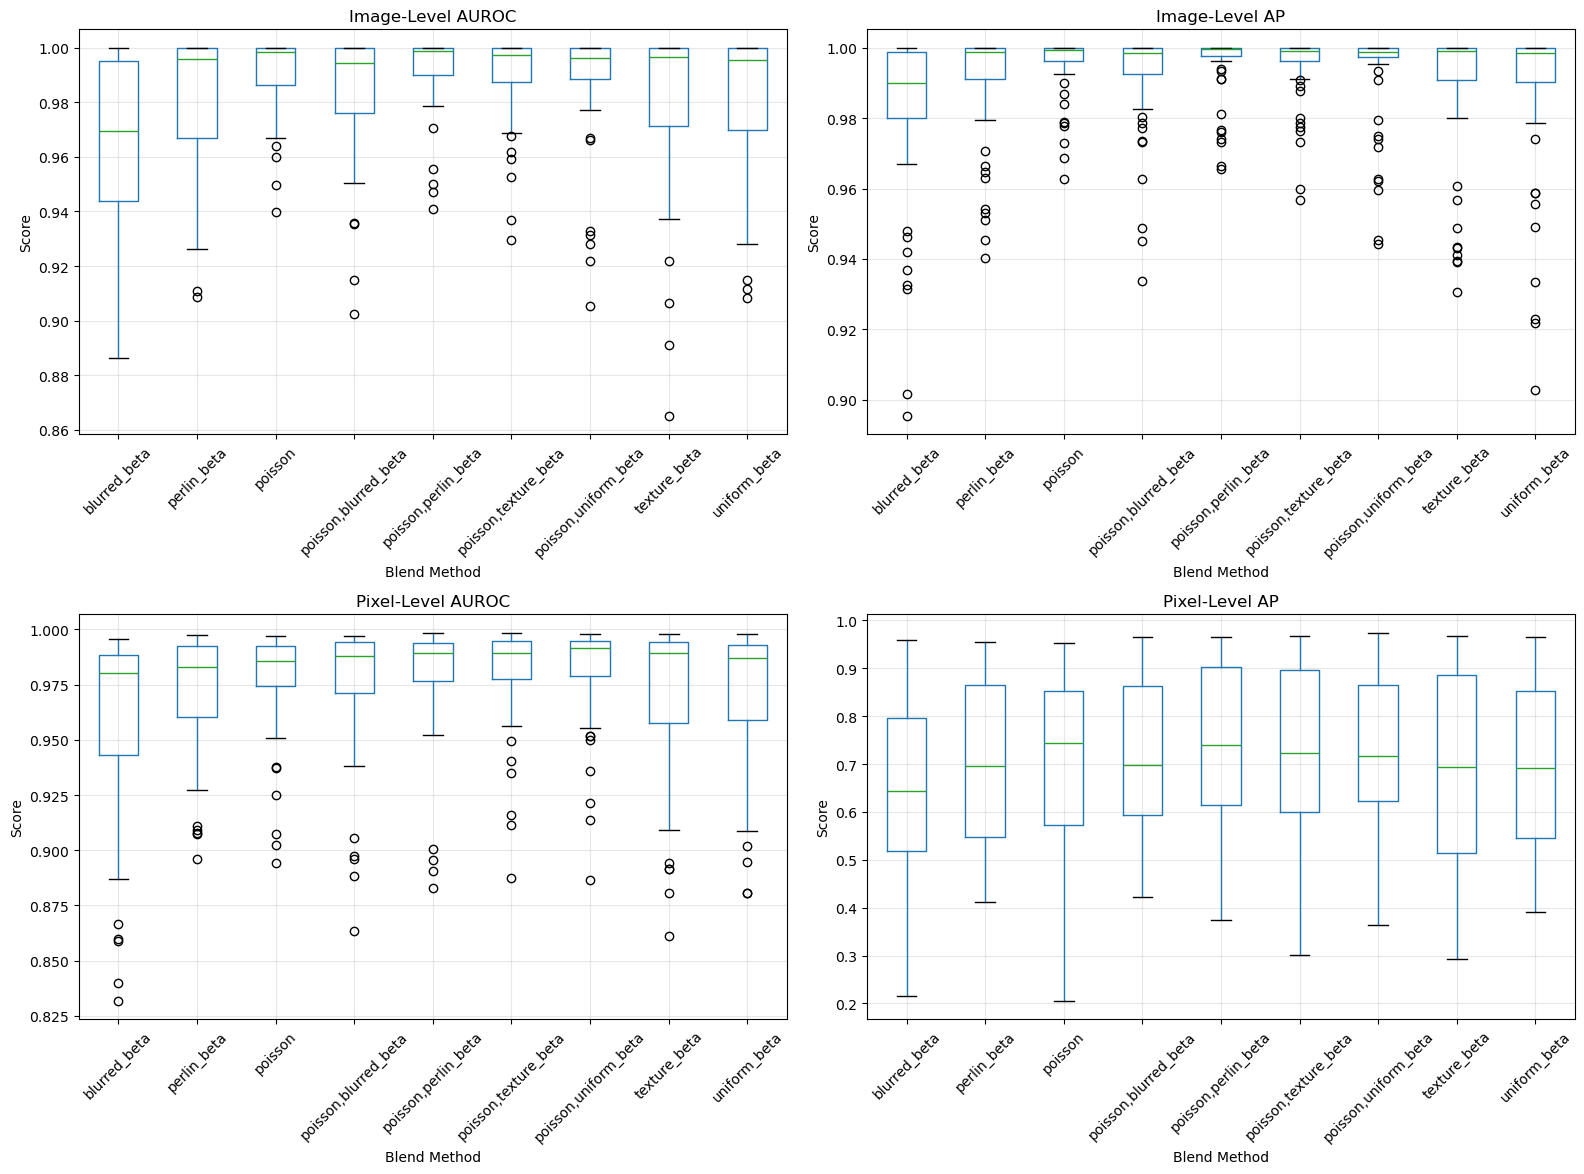

In [9]:
# Box plots for overall comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Overall Performance by Blend Method', fontsize=16, fontweight='bold')

metric_titles = [
    'Image-Level AUROC',
    'Image-Level AP',
    'Pixel-Level AUROC',
    'Pixel-Level AP'
]

for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Box plot
    df_clean.boxplot(column=metric, by='blend_method', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Blend Method')
    ax.set_ylabel('Score')
    ax.get_figure().suptitle('')  # Remove default title
    
    # Rotate x labels if needed
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

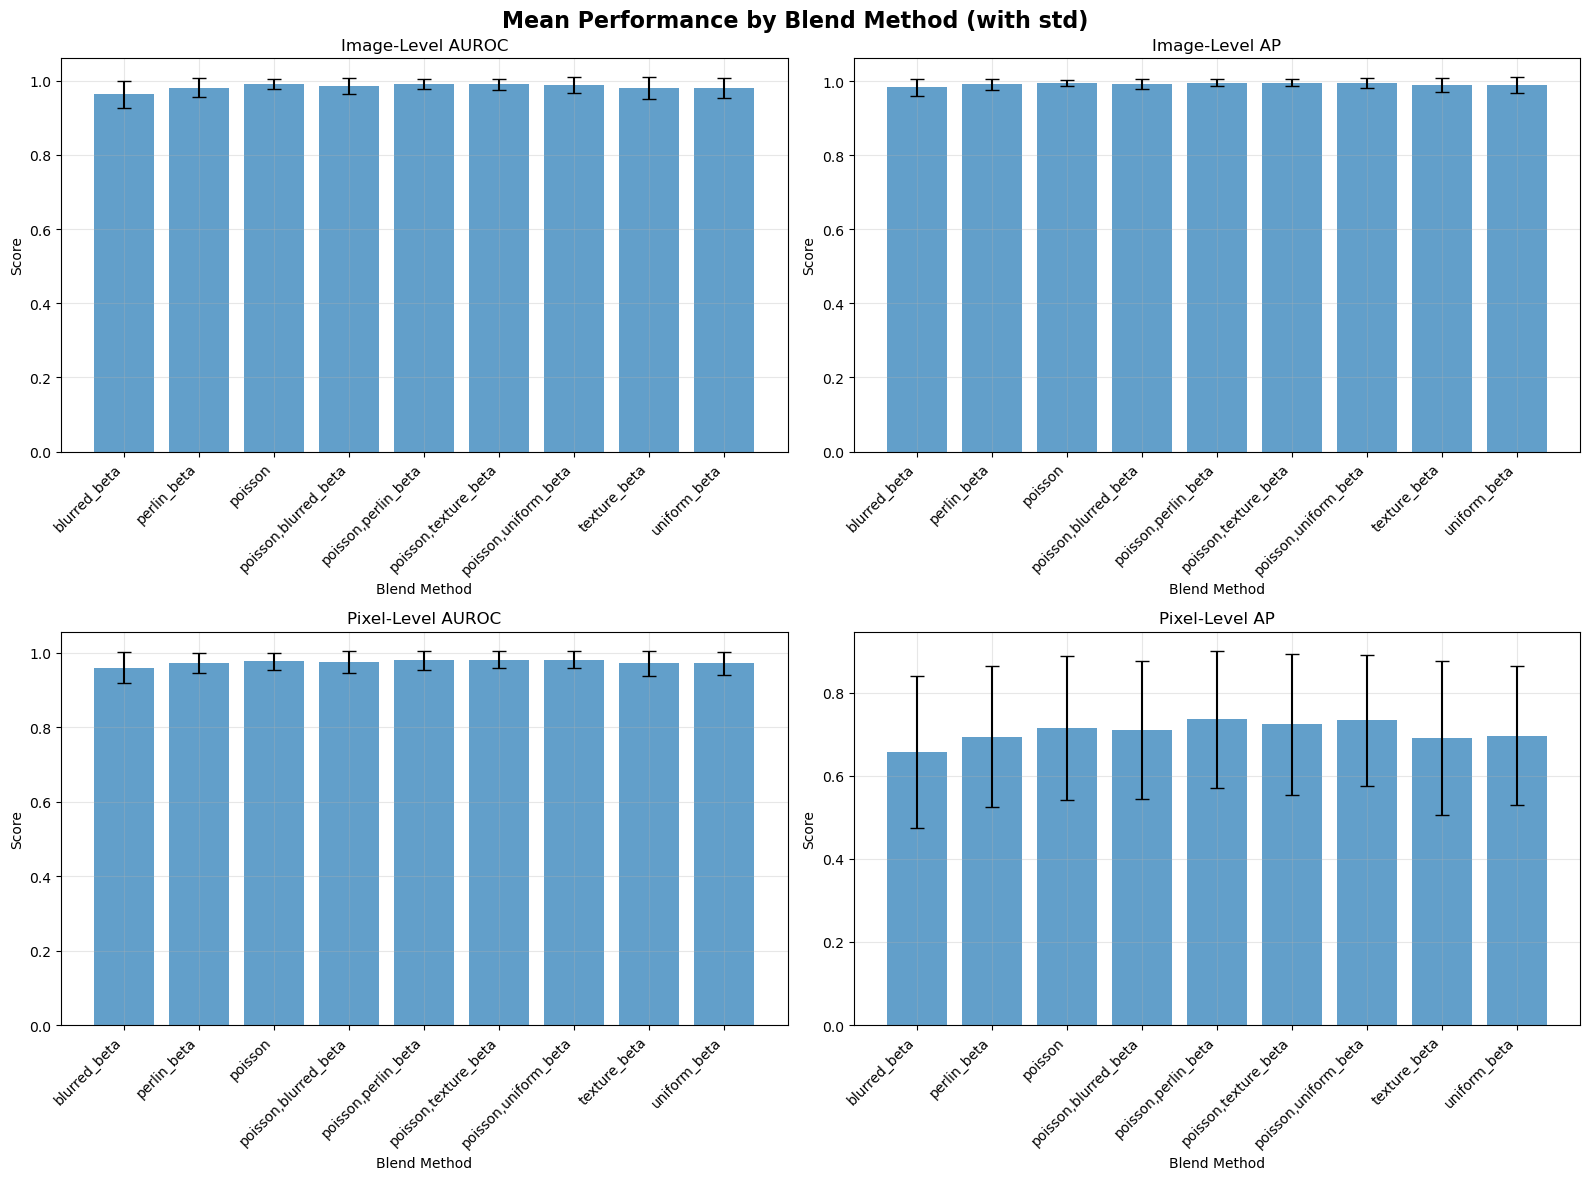

In [10]:
# Bar plots with error bars
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Mean Performance by Blend Method (with std)', fontsize=16, fontweight='bold')

for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Calculate mean and std
    grouped = df_clean.groupby('blend_method')[metric].agg(['mean', 'std'])
    
    # Bar plot
    x_pos = np.arange(len(grouped))
    ax.bar(x_pos, grouped['mean'], yerr=grouped['std'], capsize=5, alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(grouped.index, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_xlabel('Blend Method')
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Per-Object Analysis

In [11]:
# Get list of objects and blend methods
objects = sorted(df_clean['obj_name'].unique())
blend_methods = sorted(df_clean['blend_method'].unique())

print(f"Objects: {objects}")
print(f"Blend methods: {blend_methods}")

Objects: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']
Blend methods: ['blurred_beta', 'perlin_beta', 'poisson', 'poisson,blurred_beta', 'poisson,perlin_beta', 'poisson,texture_beta', 'poisson,uniform_beta', 'texture_beta', 'uniform_beta']


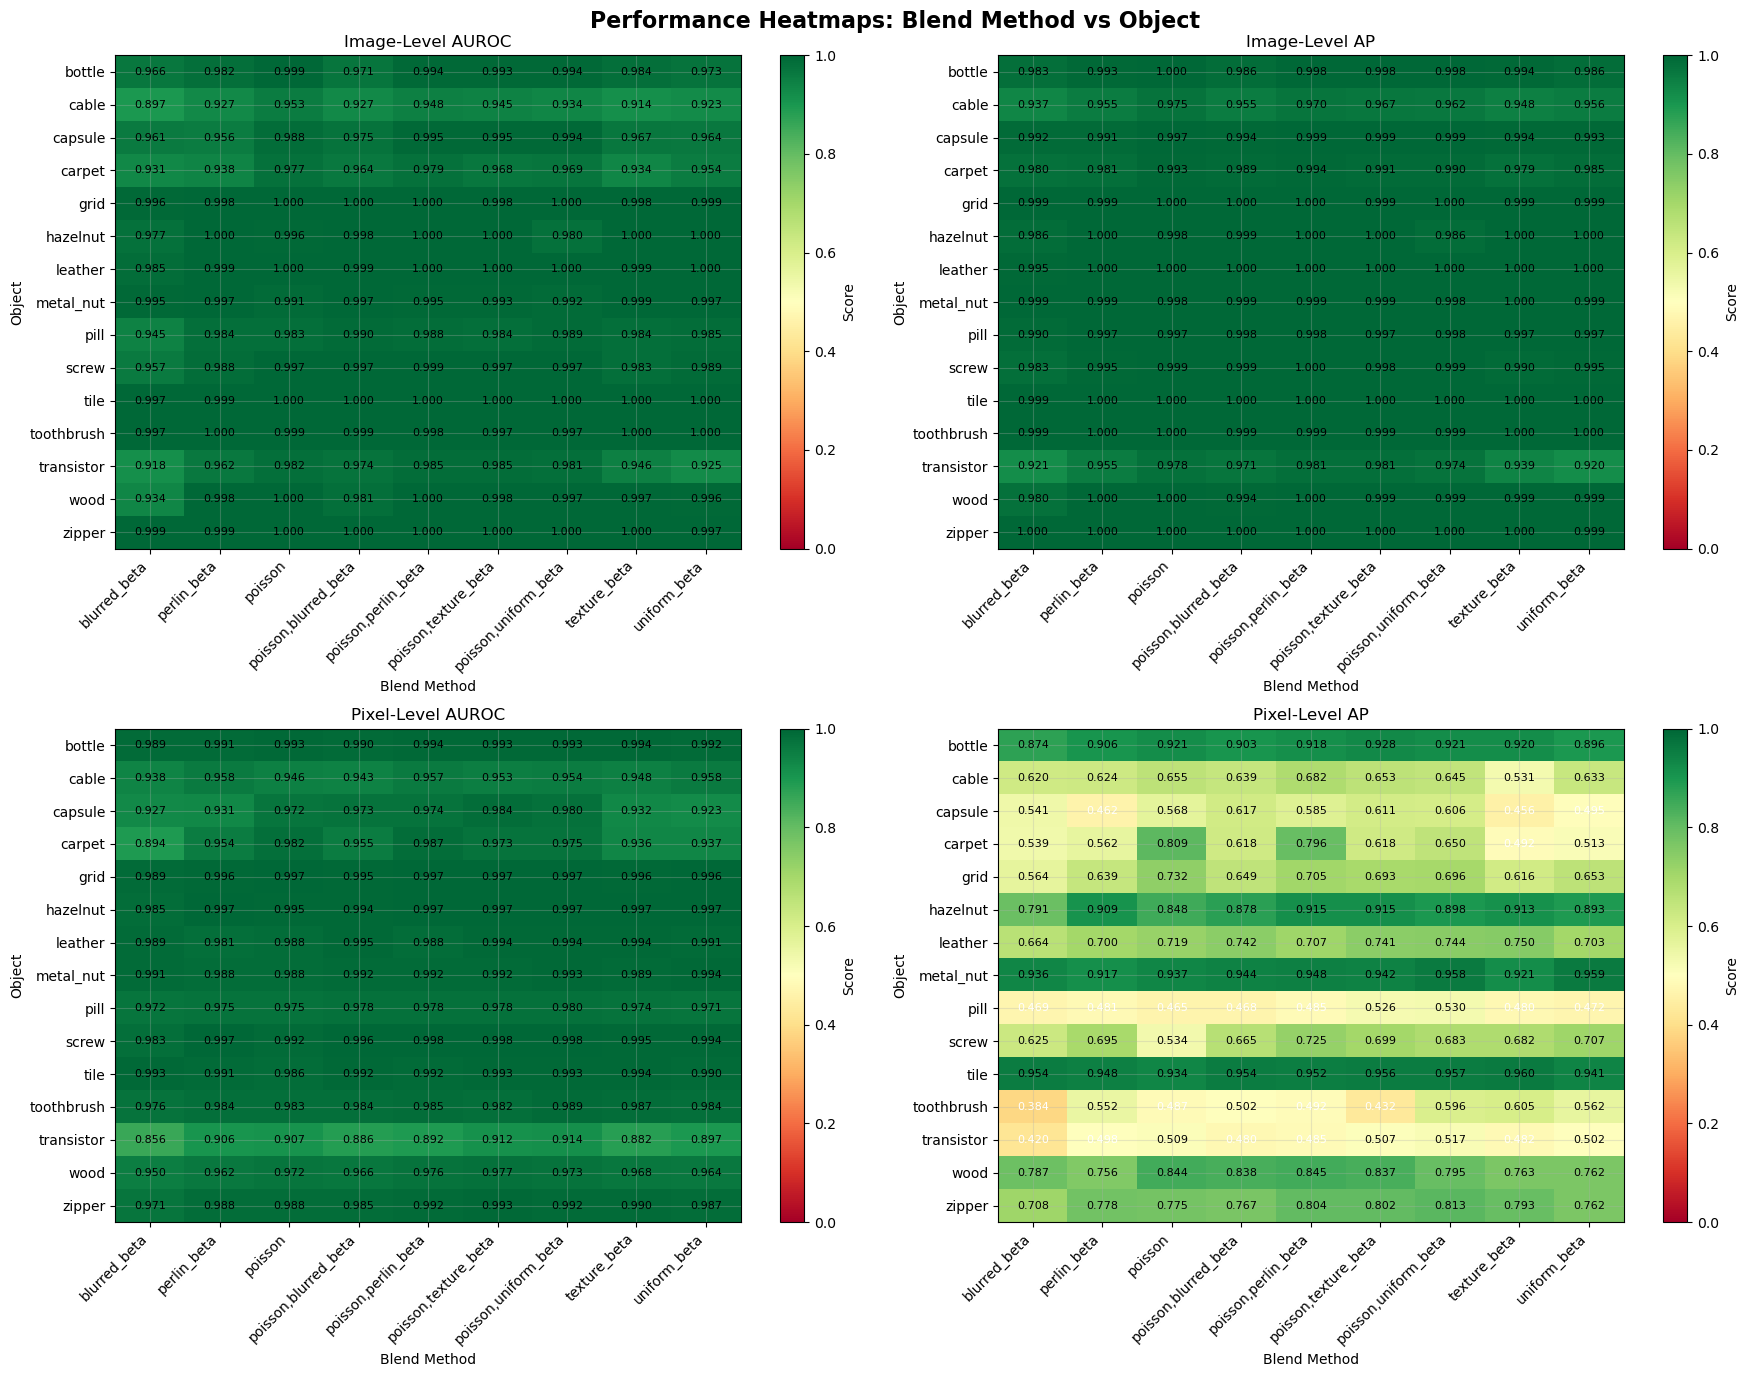

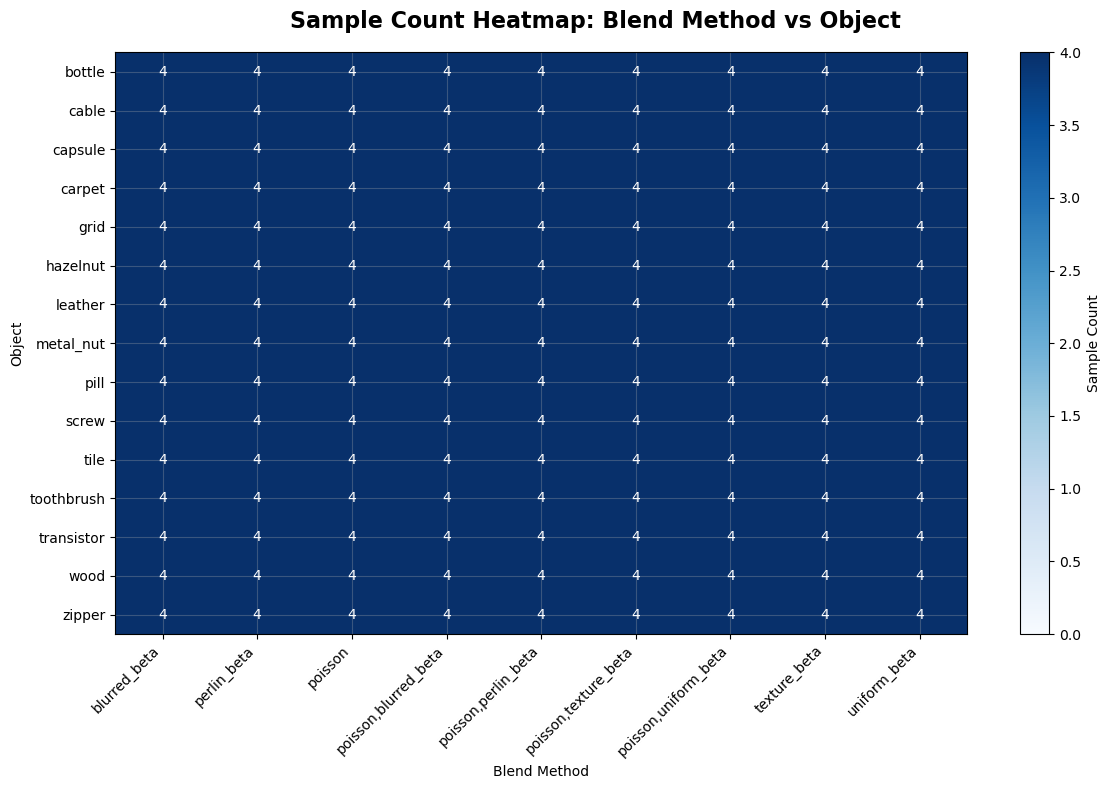

In [12]:
# Heatmap: Image-level AUROC by object and blend method
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Performance Heatmaps: Blend Method vs Object', fontsize=16, fontweight='bold')

for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Create pivot table
    pivot_data = df_clean.pivot_table(
        values=metric,
        index='obj_name',
        columns='blend_method',
        aggfunc='mean'
    )
    
    # Heatmap using matplotlib
    im = ax.imshow(pivot_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(pivot_data.columns)))
    ax.set_yticks(np.arange(len(pivot_data.index)))
    ax.set_xticklabels(pivot_data.columns, rotation=45, ha='right')
    ax.set_yticklabels(pivot_data.index)
    
    # Add text annotations
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            value = pivot_data.values[i, j]
            if not np.isnan(value):
                text_color = 'white' if value < 0.5 else 'black'
                ax.text(j, i, f'{value:.3f}', ha='center', va='center', color=text_color, fontsize=8)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Score')
    
    ax.set_title(title)
    ax.set_xlabel('Blend Method')
    ax.set_ylabel('Object')

plt.tight_layout()
plt.show()
fig.savefig('report/figures/blending_comparison_heatmap.pdf', format='pdf', dpi=300)

# Count-based heatmap: Sample count by object and blend method
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
fig.suptitle('Sample Count Heatmap: Blend Method vs Object', fontsize=16, fontweight='bold')

# Create pivot table for counts
count_data = df_clean.pivot_table(
    values='run_id',  # Use run_id as dummy variable to count
    index='obj_name',
    columns='blend_method',
    aggfunc='count',
    fill_value=0
)

# Heatmap using matplotlib
im = ax.imshow(count_data.values, cmap='Blues', aspect='auto', vmin=0, vmax=count_data.values.max())

# Set ticks and labels
ax.set_xticks(np.arange(len(count_data.columns)))
ax.set_yticks(np.arange(len(count_data.index)))
ax.set_xticklabels(count_data.columns, rotation=45, ha='right')
ax.set_yticklabels(count_data.index)

# Add count annotations
for i in range(len(count_data.index)):
    for j in range(len(count_data.columns)):
        count = count_data.values[i, j]
        text_color = 'white' if count > count_data.values.max() * 0.5 else 'black'
        ax.text(j, i, f'{count}', ha='center', va='center', color=text_color, fontsize=10)

# Add colorbar
plt.colorbar(im, ax=ax, label='Sample Count')

ax.set_xlabel('Blend Method')
ax.set_ylabel('Object')

plt.tight_layout()
plt.show()

## 6. Detailed Per-Object Comparison

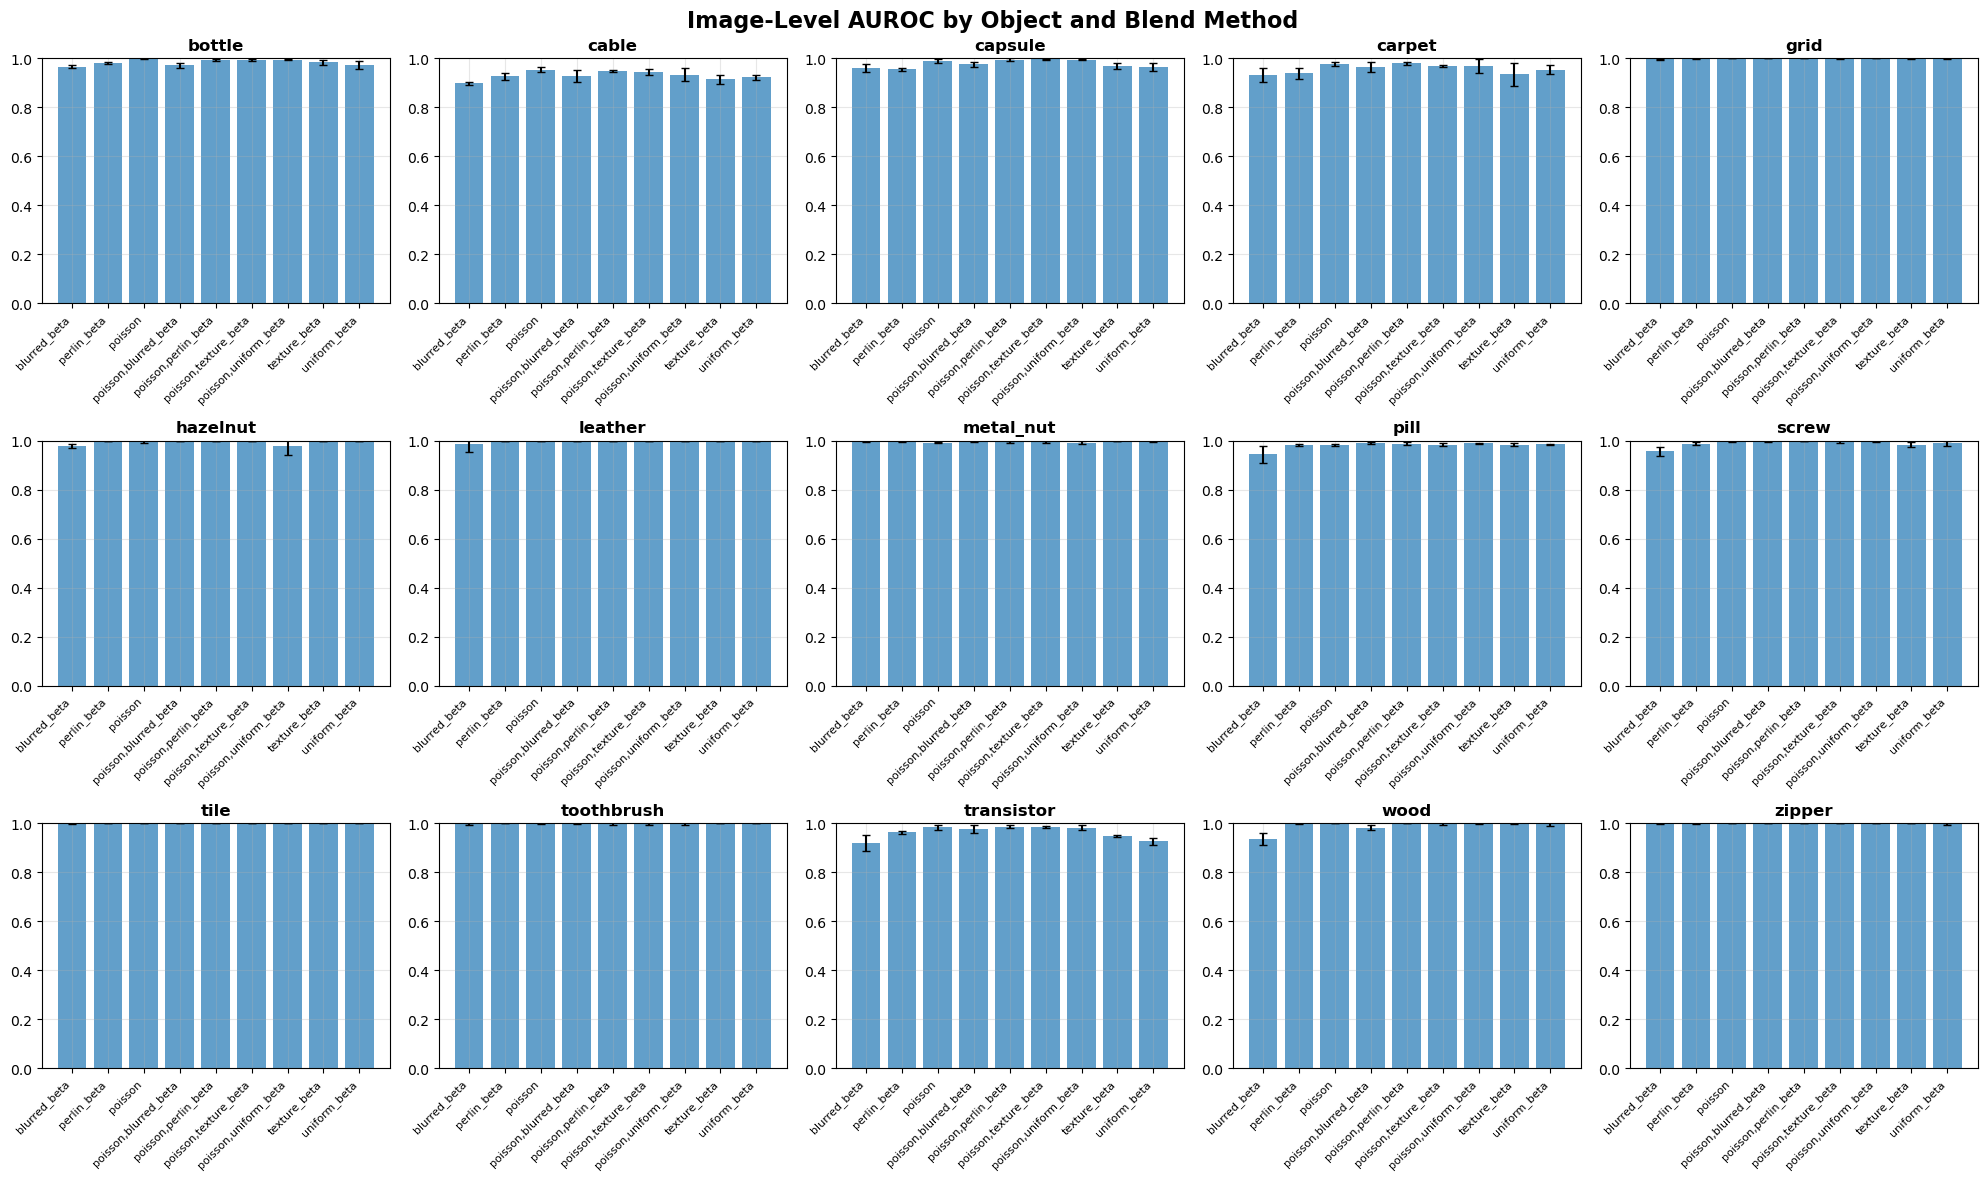

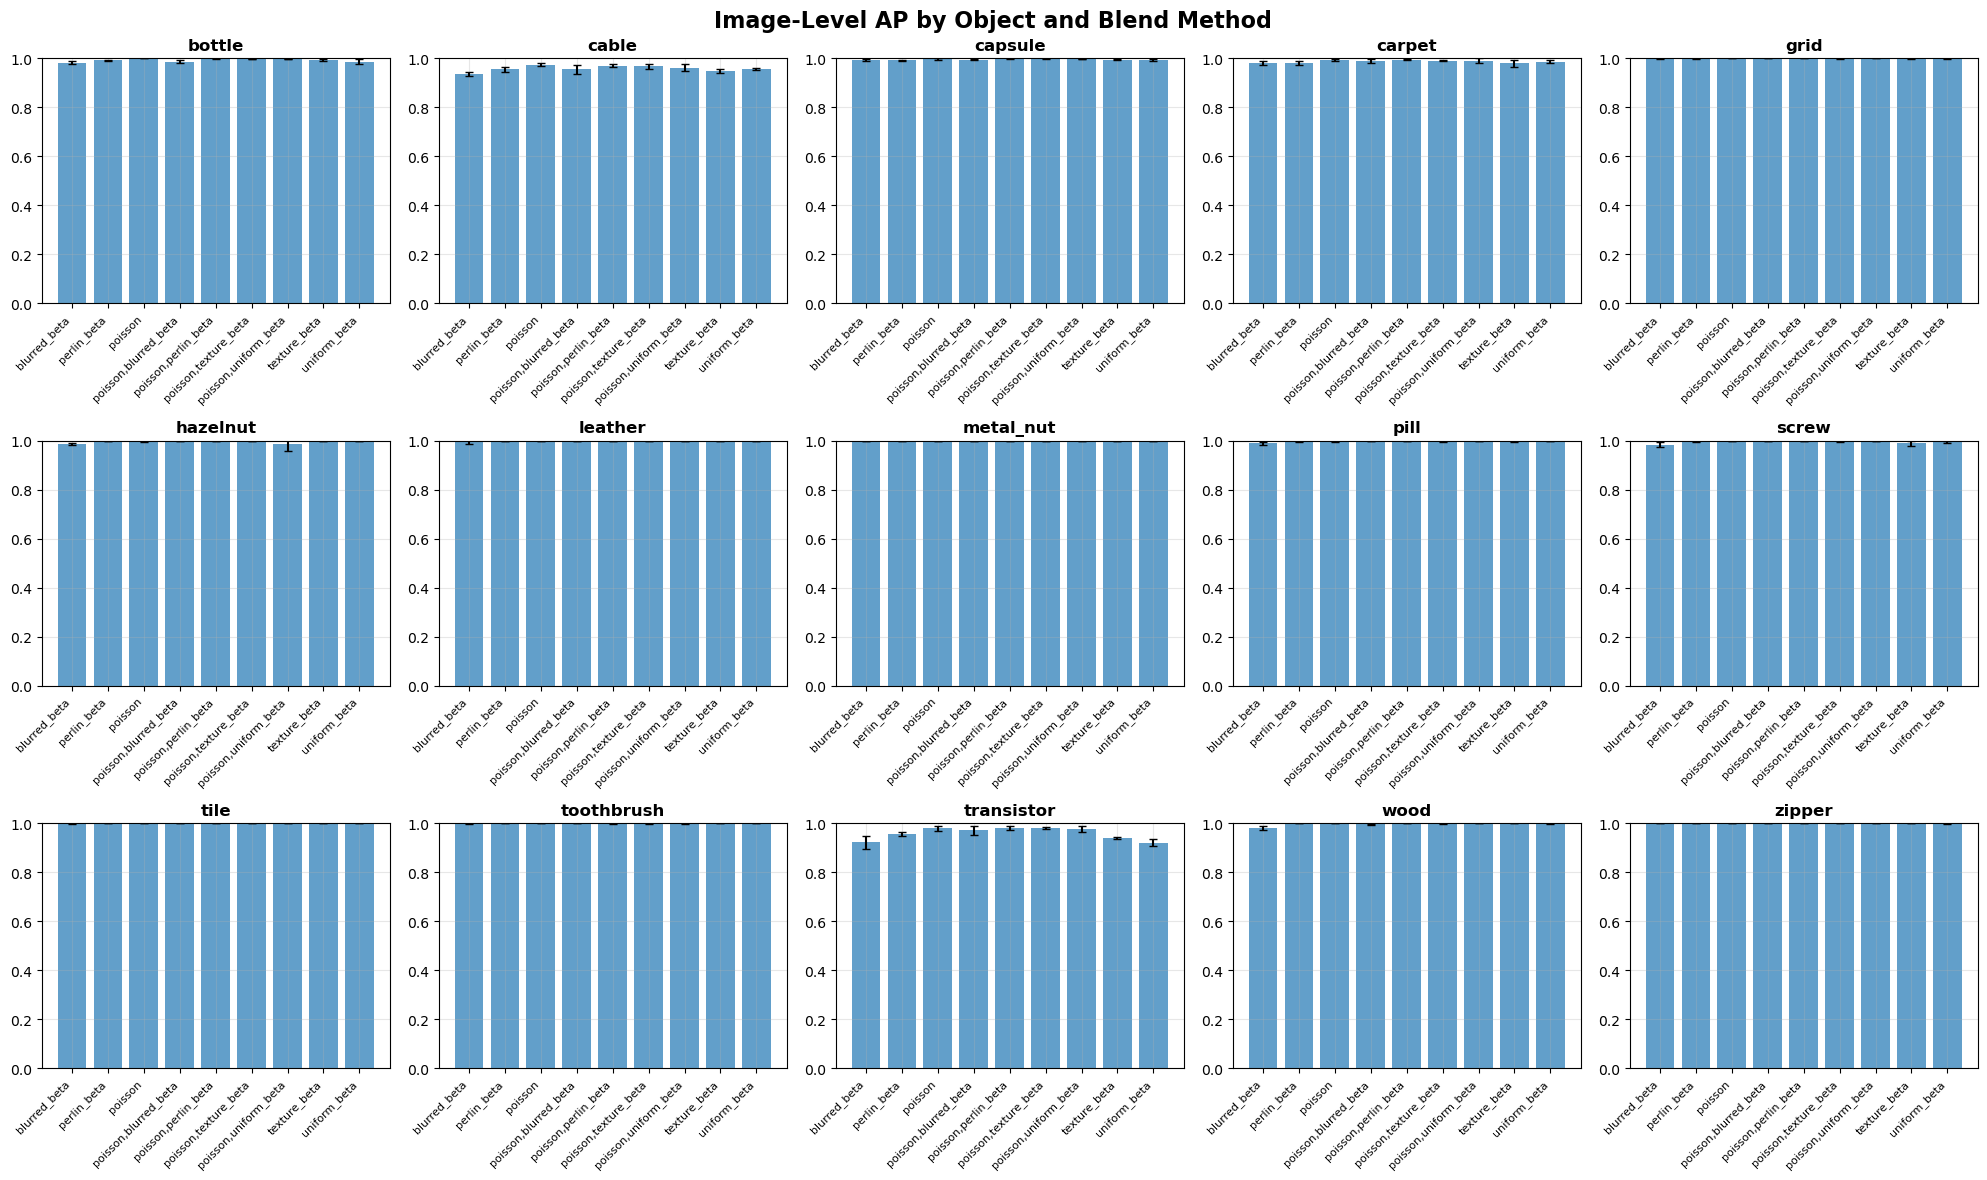

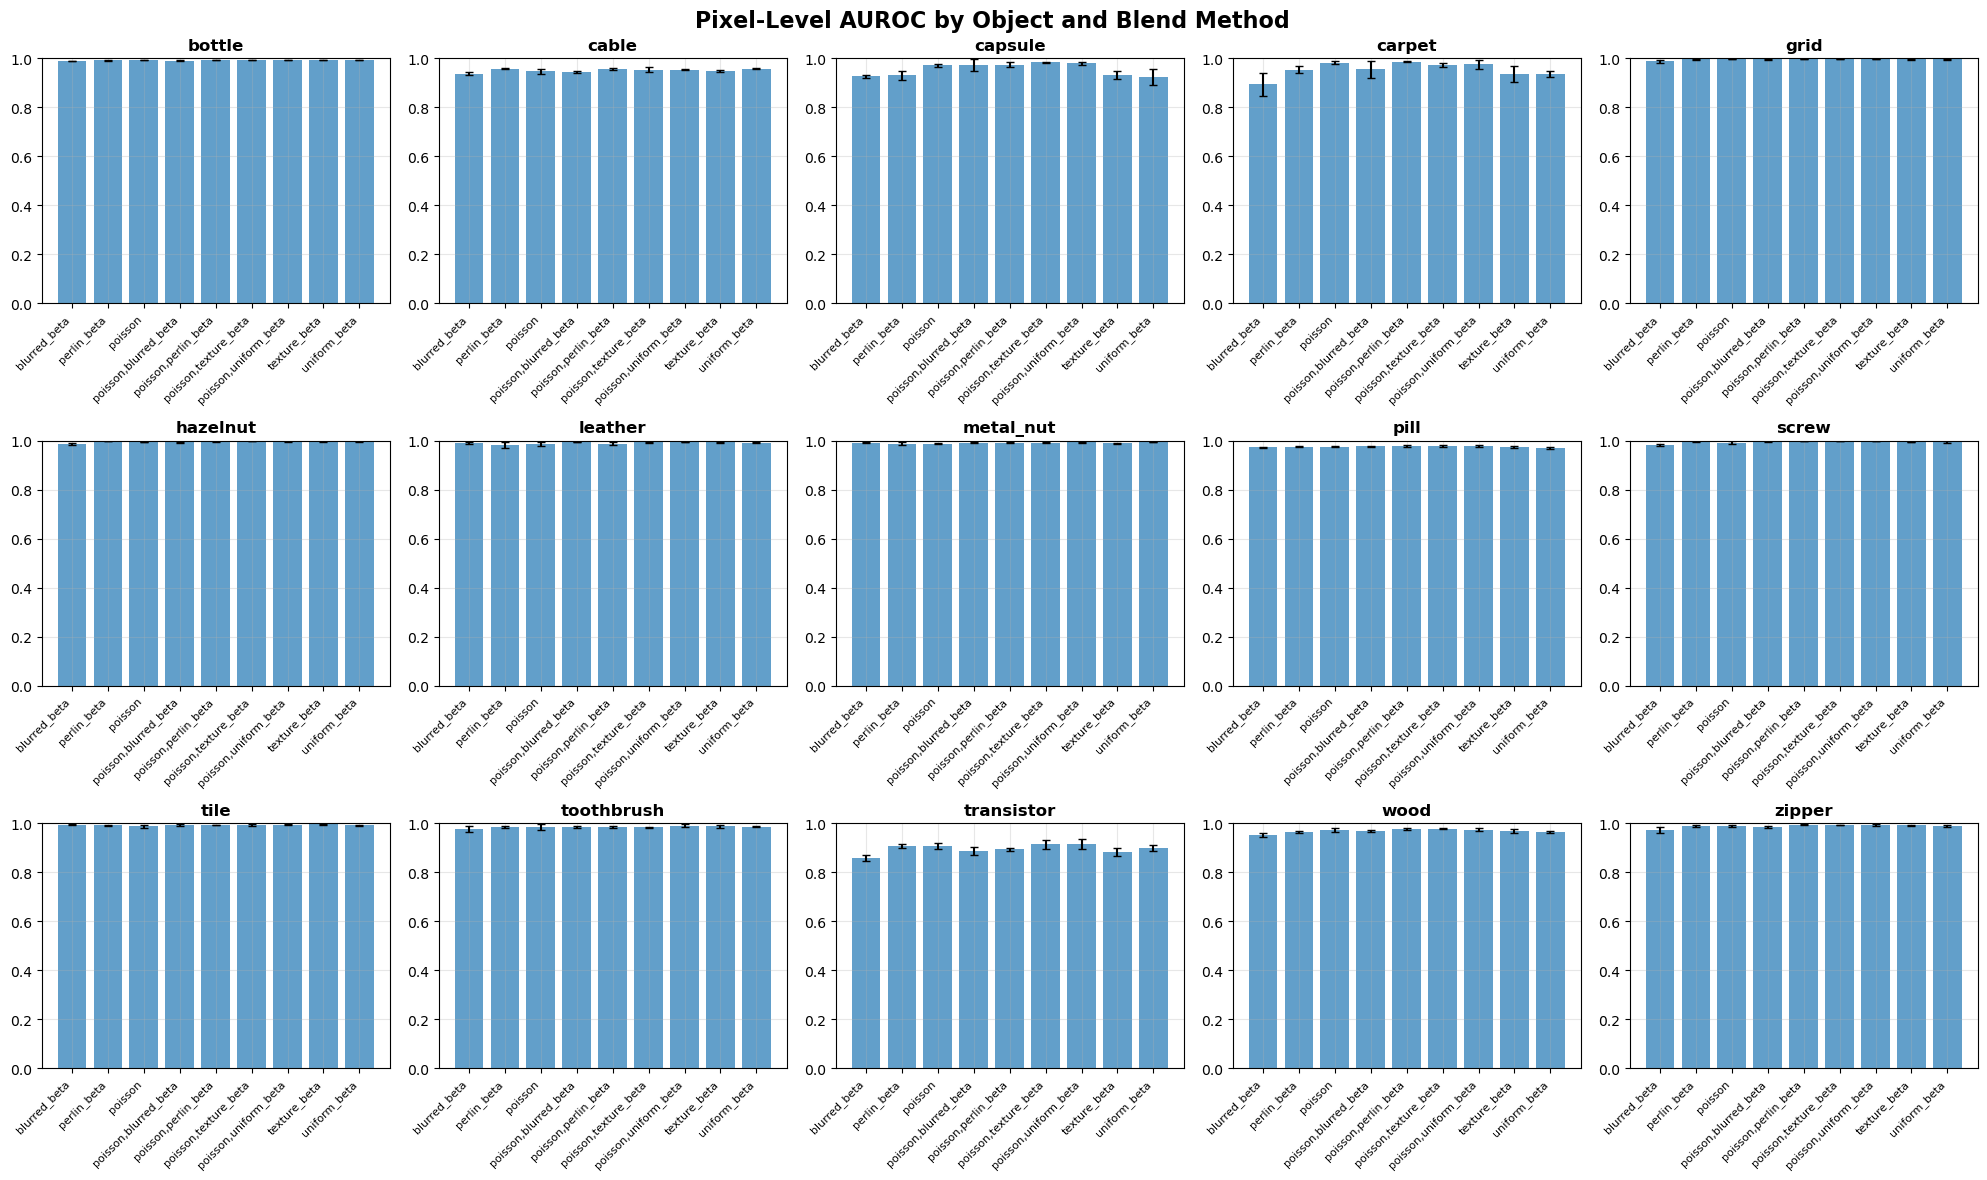

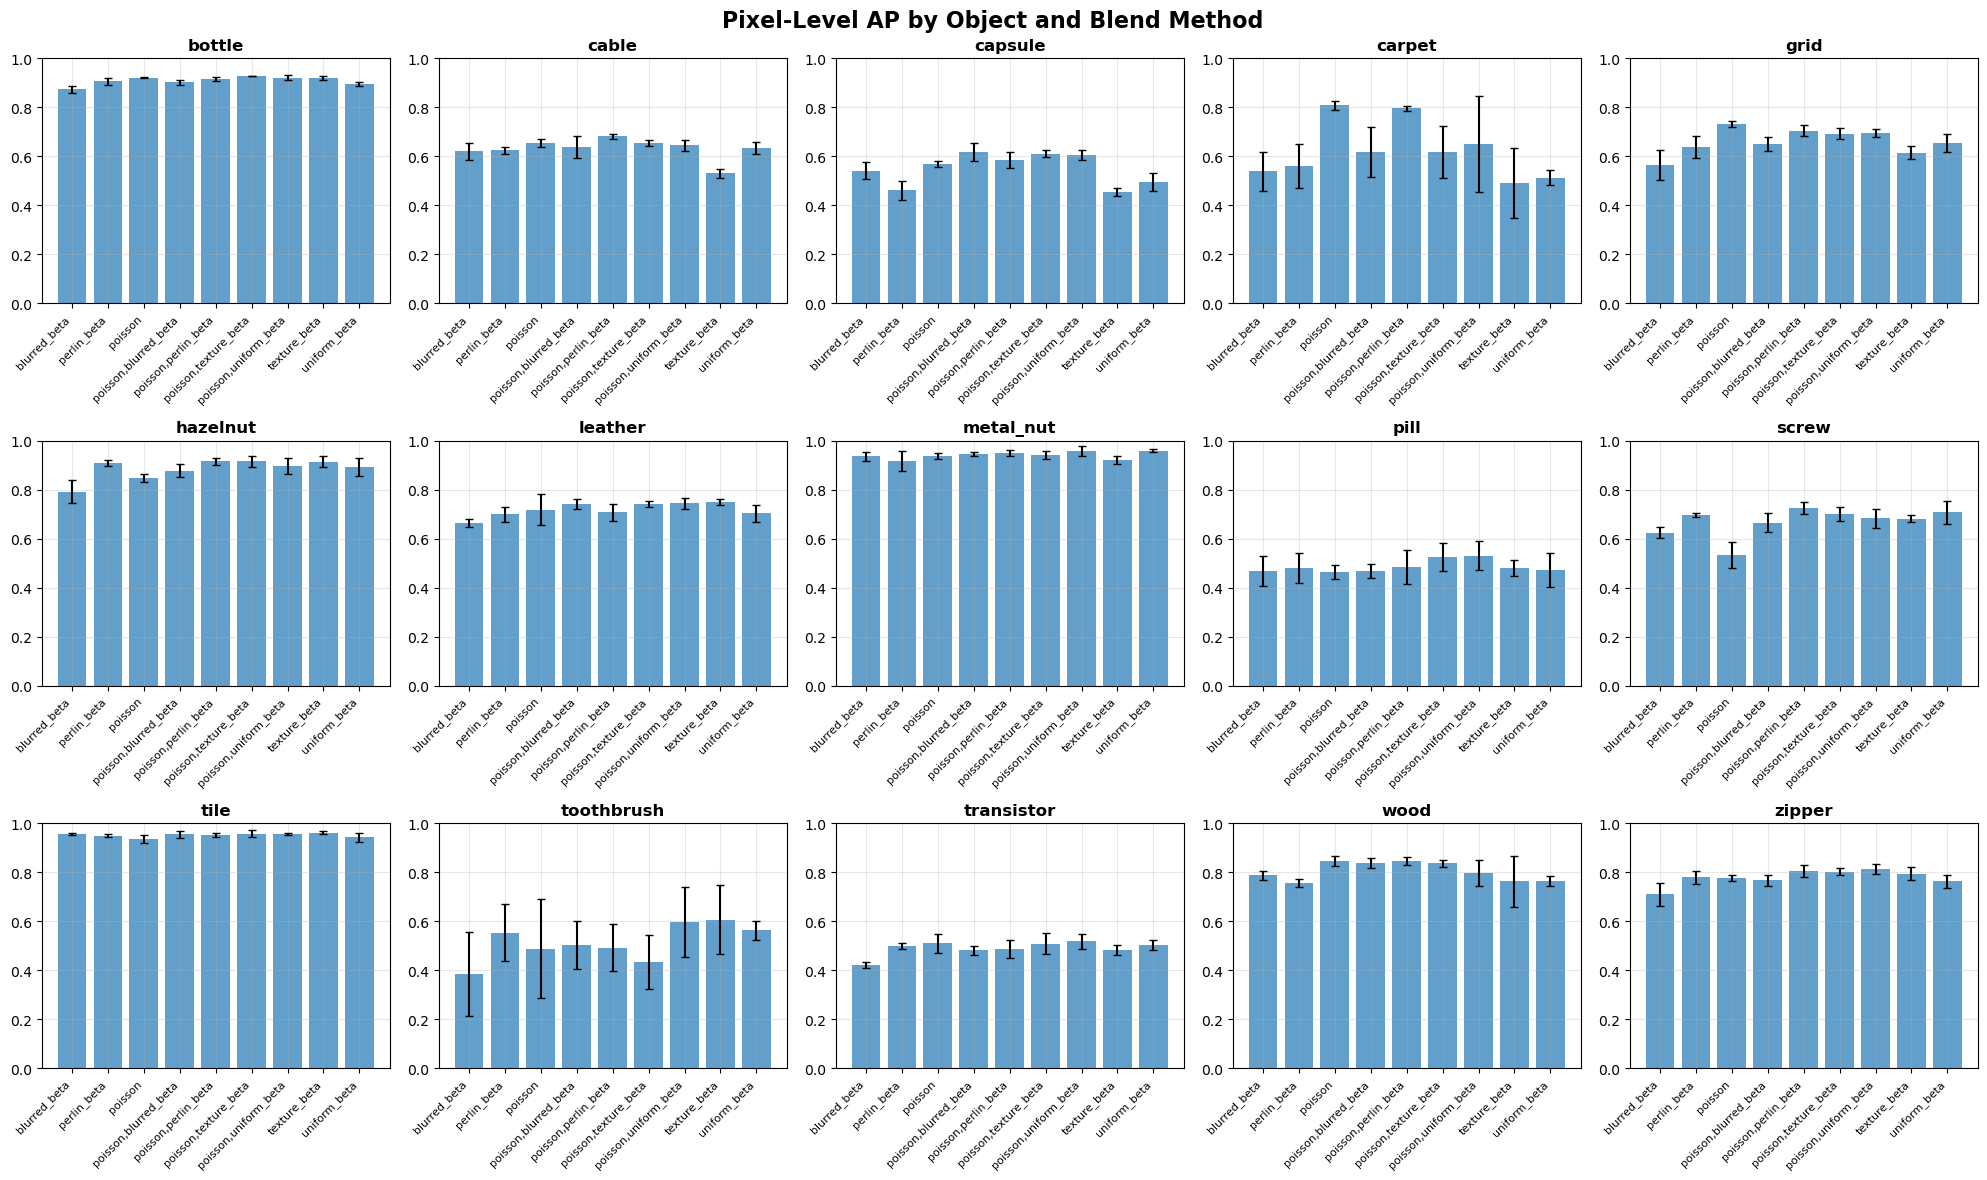

In [13]:
# Line plots: Each object's performance across blend methods
def plot_metric_by_object(metric, title):
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    fig.suptitle(f'{title} by Object and Blend Method', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    for idx, obj in enumerate(objects):
        if idx >= len(axes):
            break
        
        ax = axes[idx]
        obj_data = df_clean[df_clean['obj_name'] == obj]
        
        # Group by blend method
        grouped = obj_data.groupby('blend_method')[metric].agg(['mean', 'std'])
        
        if len(grouped) > 0:
            x_pos = np.arange(len(grouped))
            ax.bar(x_pos, grouped['mean'], yerr=grouped['std'], capsize=3, alpha=0.7)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(grouped.index, rotation=45, ha='right', fontsize=8)
            ax.set_title(obj, fontweight='bold')
            ax.set_ylim([0, 1])
            ax.grid(axis='y', alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(obj, fontweight='bold')
    
    # Hide unused subplots
    for idx in range(len(objects), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot for each metric
for metric, title in zip(metrics, metric_titles):
    plot_metric_by_object(metric, title)

## 7. Statistical Comparison

In [14]:
# Pairwise comparison of blend methods
from scipy import stats

def pairwise_ttest(df, metric, blend_methods):
    """Perform pairwise t-tests between blend methods"""
    results = pd.DataFrame(index=blend_methods, columns=blend_methods)
    
    for method1 in blend_methods:
        for method2 in blend_methods:
            if method1 == method2:
                results.loc[method1, method2] = 1.0
            else:
                data1 = df[df['blend_method'] == method1][metric].values
                data2 = df[df['blend_method'] == method2][metric].values
                
                if len(data1) > 1 and len(data2) > 1:
                    _, p_value = stats.ttest_ind(data1, data2)
                    results.loc[method1, method2] = p_value
                else:
                    results.loc[method1, method2] = np.nan
    
    return results.astype(float)

# Perform t-tests for each metric
for metric, title in zip(metrics, metric_titles):
    print(f"\n{'='*60}")
    print(f"Pairwise t-test p-values for {title}")
    print(f"{'='*60}")
    
    p_values = pairwise_ttest(df_clean, metric, blend_methods)
    print(p_values)
    print("\nNote: p < 0.05 indicates significant difference")


Pairwise t-test p-values for Image-Level AUROC
                      blurred_beta  perlin_beta       poisson  \
blurred_beta          1.000000e+00     0.001604  1.982172e-07   
perlin_beta           1.604439e-03     1.000000  1.238535e-02   
poisson               1.982172e-07     0.012385  1.000000e+00   
poisson,blurred_beta  1.566319e-04     0.481949  6.118587e-02   
poisson,perlin_beta   7.516611e-08     0.005410  6.590180e-01   
poisson,texture_beta  6.465127e-07     0.027021  7.663565e-01   
poisson,uniform_beta  1.185763e-05     0.125959  3.987377e-01   
texture_beta          6.073983e-03     0.785388  1.333060e-02   
uniform_beta          5.534521e-03     0.720717  6.404853e-03   

                      poisson,blurred_beta  poisson,perlin_beta  \
blurred_beta                      0.000157         7.516611e-08   
perlin_beta                       0.481949         5.410168e-03   
poisson                           0.061186         6.590180e-01   
poisson,blurred_beta             

## 8. Ranking Analysis

In [15]:
# Rank blend methods by average performance
ranking_data = []

for metric, title in zip(metrics, metric_titles):
    ranked = df_clean.groupby('blend_method')[metric].mean().sort_values(ascending=False)
    
    print(f"\n{title} Rankings:")
    print("-" * 40)
    for rank, (method, score) in enumerate(ranked.items(), 1):
        count = len(df_clean[df_clean['blend_method'] == method])
        print(f"{rank}. {method:20s} {score:.4f} (n={count})")
        ranking_data.append({
            'metric': title,
            'rank': rank,
            'blend_method': method,
            'score': score,
            'count': count
        })

# Create ranking DataFrame
ranking_df = pd.DataFrame(ranking_data)


Image-Level AUROC Rankings:
----------------------------------------
1. poisson,perlin_beta  0.9921 (n=60)
2. poisson              0.9910 (n=60)
3. poisson,texture_beta 0.9902 (n=60)
4. poisson,uniform_beta 0.9882 (n=60)
5. poisson,blurred_beta 0.9848 (n=60)
6. perlin_beta          0.9818 (n=60)
7. texture_beta         0.9804 (n=60)
8. uniform_beta         0.9801 (n=60)
9. blurred_beta         0.9636 (n=60)

Image-Level AP Rankings:
----------------------------------------
1. poisson,perlin_beta  0.9958 (n=60)
2. poisson              0.9956 (n=60)
3. poisson,texture_beta 0.9951 (n=60)
4. poisson,uniform_beta 0.9935 (n=60)
5. poisson,blurred_beta 0.9922 (n=60)
6. perlin_beta          0.9910 (n=60)
7. texture_beta         0.9891 (n=60)
8. uniform_beta         0.9886 (n=60)
9. blurred_beta         0.9827 (n=60)

Pixel-Level AUROC Rankings:
----------------------------------------
1. poisson,uniform_beta 0.9814 (n=60)
2. poisson,texture_beta 0.9811 (n=60)
3. poisson,perlin_beta  0.9800 (n

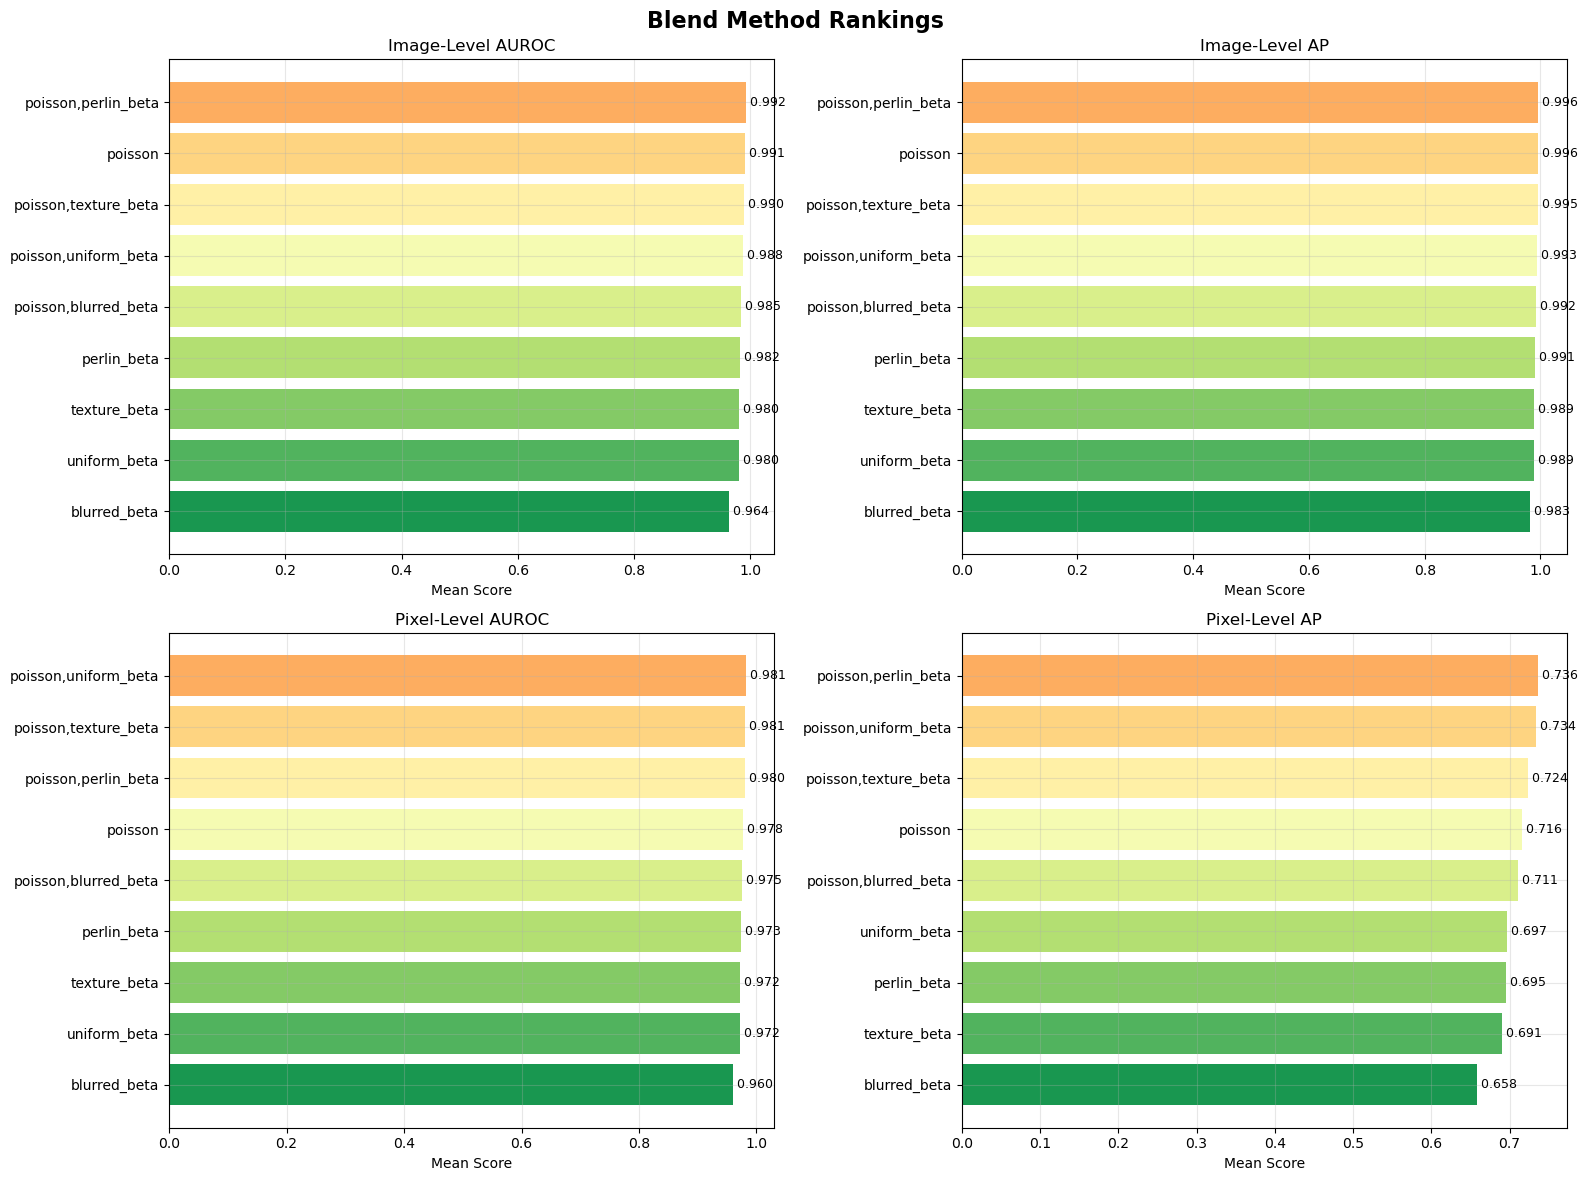

In [16]:
# Visualize rankings
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Blend Method Rankings', fontsize=16, fontweight='bold')

for idx, title in enumerate(metric_titles):
    ax = axes[idx // 2, idx % 2]
    
    data = ranking_df[ranking_df['metric'] == title].sort_values('rank')
    
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(data)))
    bars = ax.barh(data['blend_method'], data['score'], color=colors)
    
    ax.set_xlabel('Mean Score')
    ax.set_title(title)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Add score labels
    for i, (score, method) in enumerate(zip(data['score'], data['blend_method'])):
        ax.text(score, i, f' {score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
fig.savefig('report/figures/blending_comparison_combined.pdf', format='pdf', dpi=300)

## 9. Best Blend Method per Object

In [17]:
# Find best blend method for each object
best_methods = {}

for metric, title in zip(metrics, metric_titles):
    print(f"\n{title}:")
    print("=" * 60)
    
    best_for_obj = {}
    
    for obj in objects:
        obj_data = df_clean[df_clean['obj_name'] == obj]
        if len(obj_data) > 0:
            best_method = obj_data.groupby('blend_method')[metric].mean().idxmax()
            best_score = obj_data.groupby('blend_method')[metric].mean().max()
            best_for_obj[obj] = (best_method, best_score)
            print(f"{obj:15s} -> {best_method:20s} (score: {best_score:.4f})")
    
    best_methods[title] = best_for_obj


Image-Level AUROC:
bottle          -> poisson              (score: 0.9994)
cable           -> poisson              (score: 0.9533)
capsule         -> poisson,texture_beta (score: 0.9954)
carpet          -> poisson,perlin_beta  (score: 0.9794)
grid            -> poisson              (score: 1.0000)
hazelnut        -> perlin_beta          (score: 1.0000)
leather         -> poisson,perlin_beta  (score: 1.0000)
metal_nut       -> texture_beta         (score: 0.9985)
pill            -> poisson,blurred_beta (score: 0.9900)
screw           -> poisson,perlin_beta  (score: 0.9987)
tile            -> poisson              (score: 1.0000)
toothbrush      -> perlin_beta          (score: 1.0000)
transistor      -> poisson,perlin_beta  (score: 0.9852)
wood            -> poisson,perlin_beta  (score: 0.9998)
zipper          -> poisson,blurred_beta (score: 1.0000)

Image-Level AP:
bottle          -> poisson              (score: 0.9998)
cable           -> poisson              (score: 0.9748)
capsule    

In [18]:
# Count how often each blend method is the best
print("\nHow often is each blend method the best?")
print("=" * 60)

for title in metric_titles:
    print(f"\n{title}:")
    methods_count = defaultdict(int)
    
    for obj, (method, score) in best_methods[title].items():
        methods_count[method] += 1
    
    for method, count in sorted(methods_count.items(), key=lambda x: x[1], reverse=True):
        print(f"  {method:20s}: {count:2d} objects ({count/len(objects)*100:.1f}%)")


How often is each blend method the best?

Image-Level AUROC:
  poisson,perlin_beta :  5 objects (33.3%)
  poisson             :  4 objects (26.7%)
  perlin_beta         :  2 objects (13.3%)
  poisson,blurred_beta:  2 objects (13.3%)
  poisson,texture_beta:  1 objects (6.7%)
  texture_beta        :  1 objects (6.7%)

Image-Level AP:
  poisson             :  4 objects (26.7%)
  poisson,perlin_beta :  4 objects (26.7%)
  poisson,texture_beta:  2 objects (13.3%)
  perlin_beta         :  2 objects (13.3%)
  poisson,blurred_beta:  2 objects (13.3%)
  texture_beta        :  1 objects (6.7%)

Pixel-Level AUROC:
  poisson,texture_beta:  4 objects (26.7%)
  poisson,perlin_beta :  3 objects (20.0%)
  poisson,uniform_beta:  3 objects (20.0%)
  texture_beta        :  2 objects (13.3%)
  perlin_beta         :  1 objects (6.7%)
  poisson,blurred_beta:  1 objects (6.7%)
  uniform_beta        :  1 objects (6.7%)

Pixel-Level AP:
  poisson,perlin_beta :  3 objects (20.0%)
  texture_beta        :  3 obj

## 10. Summary and Conclusions

In [19]:
# Overall summary
print("\n" + "="*80)
print("SUMMARY: Blend Method Performance Analysis")
print("="*80)

print(f"\nTotal runs analyzed: {len(df_clean)}")
print(f"Blend methods: {len(blend_methods)}")
print(f"Objects: {len(objects)}")

print("\nOverall Best Performing Blend Methods:")
print("-" * 80)

for metric, title in zip(metrics, metric_titles):
    best_overall = df_clean.groupby('blend_method')[metric].mean().idxmax()
    best_score = df_clean.groupby('blend_method')[metric].mean().max()
    worst_overall = df_clean.groupby('blend_method')[metric].mean().idxmin()
    worst_score = df_clean.groupby('blend_method')[metric].mean().min()
    
    print(f"\n{title}:")
    print(f"  Best:  {best_overall:20s} (mean: {best_score:.4f})")
    print(f"  Worst: {worst_overall:20s} (mean: {worst_score:.4f})")
    print(f"  Improvement: {(best_score - worst_score):.4f} ({(best_score - worst_score)/worst_score*100:.1f}%)")


SUMMARY: Blend Method Performance Analysis

Total runs analyzed: 540
Blend methods: 9
Objects: 15

Overall Best Performing Blend Methods:
--------------------------------------------------------------------------------

Image-Level AUROC:
  Best:  poisson,perlin_beta  (mean: 0.9921)
  Worst: blurred_beta         (mean: 0.9636)
  Improvement: 0.0284 (3.0%)

Image-Level AP:
  Best:  poisson,perlin_beta  (mean: 0.9958)
  Worst: blurred_beta         (mean: 0.9827)
  Improvement: 0.0131 (1.3%)

Pixel-Level AUROC:
  Best:  poisson,uniform_beta (mean: 0.9814)
  Worst: blurred_beta         (mean: 0.9602)
  Improvement: 0.0213 (2.2%)

Pixel-Level AP:
  Best:  poisson,perlin_beta  (mean: 0.7363)
  Worst: blurred_beta         (mean: 0.6584)
  Improvement: 0.0779 (11.8%)


In [20]:
# Export summary to CSV
summary_export = df_clean.groupby('blend_method')[metrics].agg(['mean', 'std', 'min', 'max', 'count'])
summary_export.to_csv('blend_method_summary.csv')
print("\nSummary statistics exported to: blend_method_summary.csv")

# Export per-object results
per_obj_export = df_clean.pivot_table(
    values=metrics,
    index='obj_name',
    columns='blend_method',
    aggfunc='mean'
)
per_obj_export.to_csv('blend_method_per_object.csv')
print("Per-object results exported to: blend_method_per_object.csv")


Summary statistics exported to: blend_method_summary.csv
Per-object results exported to: blend_method_per_object.csv


In [21]:
from matplotlib import cm, colors
import numpy as np


def df_to_latex_colored(df, cmap_name="RdYlGn", fmt="{:.1f}\\%", beamer_style=True):
    cmap = cm.get_cmap(cmap_name)
    
    # Best and second-best indices per column
    best_idx = {}
    second_idx = {}
    for col in df.columns:
        col_vals = df[col].dropna().sort_values(ascending=False)
        if len(col_vals) >= 1:
            best_idx[col] = col_vals.index[0]
        if len(col_vals) >= 2:
            second_idx[col] = col_vals.index[1]

    lines = []
    # Header row (index as first column)
    header = "\\textbf{Method} & \\textbf{" + "} $\\uparrow$ & \\textbf{".join(df.columns) + "} $\\uparrow$ \\\\"
    lines.append("\\hline")
    lines.append(header)
    lines.append("\\hline")
    uncover_counter = 0

    for idx, row in df.iterrows():
        row_cells = [str(idx)]  # first column: row label (index)
        for col, val in row.items():
            if np.isnan(val):
                cell_tex = ""
            else:
                # Per-column normalization
                col_vals = df[col].dropna()
                vmin = col_vals.min()
                vmax = col_vals.max()
                norm = colors.Normalize(vmin=vmin, vmax=vmax)
                
                rgba = cmap(norm(val))
                hex_color = colors.rgb2hex(rgba)[1:].upper()  # RRGGBB

                # Default text (assume df values in [0,1] and show percent)
                text = fmt.format(val * 100)

                # Bold / underline based on rank within the column
                if idx == best_idx.get(col):
                    text = "\\textbf{" + text + "}"
                elif idx == second_idx.get(col):
                    text = "\\underline{" + text + "}"

                cell_tex = f"\\cellcolor[HTML]{{{hex_color}}} {text}"

            row_cells.append(cell_tex)

        line = " & ".join(row_cells)
        if uncover_counter == 0:
            lines.append(line + " \\\\")
        else:
            lines.append(f"\\uncover<{uncover_counter}->{{{line}}} \\\\")
        if "Uniform" in lines[-1] and beamer_style:
            lines.append("\\hline")
        if "Poisson" in lines[-1] and beamer_style:
            lines.append("\\hline")
            uncover_counter = 4
        if not beamer_style and "+" in lines[-1]:
            lines.append("\\hline")
        

    lines = [" " * 16 + line for line in lines]
    return "\n".join(lines)

# Example usage (replace `table_df` with your own DataFrame):
# methods = ["US", "RIAD", "PaDim", "DRÆM-Uniform", "DRÆM-Blurred",
#            "DRÆM-Texture", "DRÆM-Perlin", "DRÆM-Poisson", "DRÆM-Poisson-Perlin"]
# metrics = ["Image AUROC", "Image AP", "Pixel AP"]
# table_df = pd.DataFrame(data, index=methods, columns=metrics)  # values in [0,1]
# latex_table = df_to_latex_colored(table_df)
# print(latex_table)
# In LaTeX, be sure to include: \usepackage[table]{xcolor}

In [22]:
# Table from the LaTeX snippet as a DataFrame
methods = [
    "DRÆM-Uniform",
    "DRÆM-Blurred",
    "DRÆM-Texture",
    "DRÆM-Perlin",
    "DRÆM-Poisson",
    "DRÆM-Poisson+Perlin",
]

# Values converted from percentages to fractions in [0, 1]
data = [
    [0.980, 0.973, 0.684],  # DRÆM-Uniform
    [0.964, 0.960, 0.658],  # DRÆM-Blurred
    [0.980, 0.972, 0.691],  # DRÆM-Texture
    [0.982, 0.973, 0.695],  # DRÆM-Perlin
    [0.991, 0.978, 0.716],  # DRÆM-Poisson
    [0.992, 0.980, 0.736],  # DRÆM-Poisson-Perlin
]

columns = ["Image AUROC", "Pixel AUROC", "Pixel AP"]

latex_df = pd.DataFrame(data, index=methods, columns=columns)
latex_table = " " * 12 + "\\begin{tabular}{lccc}\n" 
latex_table += df_to_latex_colored(latex_df)
latex_table += "\n" + " " * 12 + "\\end{tabular}"

with open('presentation/figures/blending_comparison_table.tex', 'w') as f:
    f.write(latex_table)

In [23]:
# Table from the LaTeX snippet as a DataFrame
methods = [
    "DRÆM-Uniform",
    "DRÆM-Blurred",
    "DRÆM-Texture",
    "DRÆM-Perlin",
    "DRÆM-Poisson",
    "DRÆM-Poisson+Perlin",
]

# Values converted from percentages to fractions in [0, 1]
data = [
    [0.980, 0.973, 0.697],  # DRÆM-Uniform
    [0.964, 0.960, 0.658],  # DRÆM-Blurred
    [0.980, 0.972, 0.691],  # DRÆM-Texture
    [0.982, 0.973, 0.695],  # DRÆM-Perlin
    [0.991, 0.978, 0.716],  # DRÆM-Poisson
    [0.992, 0.980, 0.736],  # DRÆM-Poisson-Perlin
]

columns = ["Image AUROC", "Pixel AUROC", "Pixel AP"]

latex_df = pd.DataFrame(data, index=methods, columns=columns)
latex_table = " " * 12 + "\\begin{tabular}{lccc}\n" 
latex_table += df_to_latex_colored(latex_df, beamer_style=False)
latex_table += "\n" + " " * 12 + "\\end{tabular}"

with open('report/figures/blending_comparison_table_report.tex', 'w') as f:
    f.write(latex_table)

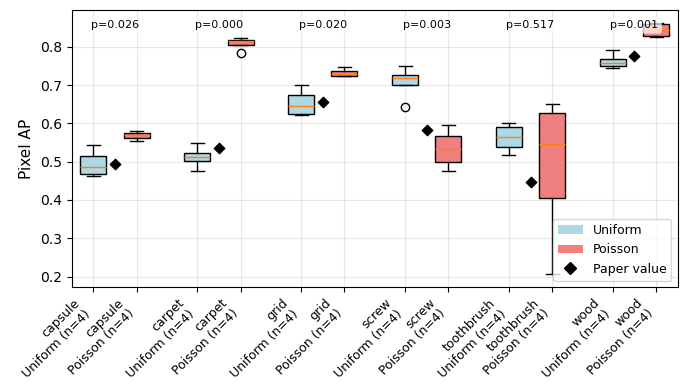

In [24]:
# Compare Uniform vs Poisson for pixel-level AP across selected objects
baseline_metrics = [
    {"obj_name": "bottle",      "eval/auroc_pixel": 0.991, "eval/ap_pixel": 0.865, "eval/auroc_image": 0.992},
    {"obj_name": "capsule",     "eval/auroc_pixel": 0.943, "eval/ap_pixel": 0.494, "eval/auroc_image": 0.985},
    {"obj_name": "grid",        "eval/auroc_pixel": 0.997, "eval/ap_pixel": 0.657, "eval/auroc_image": 0.999},
    {"obj_name": "leather",     "eval/auroc_pixel": 0.986, "eval/ap_pixel": 0.753, "eval/auroc_image": 1.000},
    {"obj_name": "pill",        "eval/auroc_pixel": 0.976, "eval/ap_pixel": 0.485, "eval/auroc_image": 0.989},
    {"obj_name": "tile",        "eval/auroc_pixel": 0.992, "eval/ap_pixel": 0.923, "eval/auroc_image": 0.996},
    {"obj_name": "transistor",  "eval/auroc_pixel": 0.909, "eval/ap_pixel": 0.507, "eval/auroc_image": 0.931},
    {"obj_name": "zipper",      "eval/auroc_pixel": 0.988, "eval/ap_pixel": 0.815, "eval/auroc_image": 1.000},
    {"obj_name": "cable",       "eval/auroc_pixel": 0.947, "eval/ap_pixel": 0.524, "eval/auroc_image": 0.918},
    {"obj_name": "carpet",      "eval/auroc_pixel": 0.955, "eval/ap_pixel": 0.535, "eval/auroc_image": 0.970},
    {"obj_name": "hazelnut",    "eval/auroc_pixel": 0.997, "eval/ap_pixel": 0.929, "eval/auroc_image": 1.000},
    {"obj_name": "metal_nut",   "eval/auroc_pixel": 0.995, "eval/ap_pixel": 0.963, "eval/auroc_image": 0.987},
    {"obj_name": "screw",       "eval/auroc_pixel": 0.976, "eval/ap_pixel": 0.582, "eval/auroc_image": 0.939},
    {"obj_name": "toothbrush",  "eval/auroc_pixel": 0.981, "eval/ap_pixel": 0.447, "eval/auroc_image": 1.000},
    {"obj_name": "wood",        "eval/auroc_pixel": 0.964, "eval/ap_pixel": 0.777, "eval/auroc_image": 0.991},
]

# Identify the blend method labels present in the data
uniform_methods = ['uniform_beta']
poisson_methods = ['poisson']

pixel_metric = "eval/ap_pixel"
selected_objects = ["capsule", "carpet", "grid", "screw", "toothbrush", "wood"]
objects_for_plot = [obj for obj in selected_objects if obj in df_clean["obj_name"].unique()]
if len(objects_for_plot) == 0:
    raise ValueError("None of the selected objects are present in df_clean.")

baseline_df = pd.DataFrame(baseline_metrics)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))

positions, data_plot, labels, colors = [], [], [], []
obj_center_pos = {}
p_values = {}
pos = 0

for obj_name in objects_for_plot:
    df_obj = df_clean[df_clean["obj_name"] == obj_name]

    # Uniform runs
    uniform_vals = df_obj[df_obj["blend_method"].isin(uniform_methods)][pixel_metric].dropna()
    if len(uniform_vals) > 0:
        positions.append(pos)
        data_plot.append(uniform_vals)
        labels.append(f"{obj_name}\nUniform (n={len(uniform_vals)})")
        colors.append("lightblue")
        pos += 1

    # Poisson runs
    poisson_vals = df_obj[df_obj["blend_method"].isin(poisson_methods)][pixel_metric].dropna()
    if len(poisson_vals) > 0:
        positions.append(pos)
        data_plot.append(poisson_vals)
        labels.append(f"{obj_name}\nPoisson (n={len(poisson_vals)})")
        colors.append("lightcoral")
        pos += 1

    if len(uniform_vals) + len(poisson_vals) > 0:
        obj_positions = positions[-(len(uniform_vals) > 0) - (len(poisson_vals) > 0):]
        if len(obj_positions) > 0:
            obj_center_pos[obj_name] = sum(obj_positions) / len(obj_positions)

    # Per-object p-value (two-sided t-test) when both groups have data
    if len(uniform_vals) > 0 and len(poisson_vals) > 0:
        _, p_val = stats.ttest_ind(uniform_vals, poisson_vals, equal_var=False, nan_policy="omit")
        p_values[obj_name] = p_val

    pos += 0.4  # spacing between objects

if len(data_plot) == 0:
    raise ValueError("No matching runs found for Uniform or Poisson blend methods for selected objects.")

bp = ax.boxplot(data_plot, positions=positions, widths=0.6, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

# Overlay paper-reported baseline as black diamonds
if pixel_metric in baseline_df.columns:
    for _, row in baseline_df.iterrows():
        obj = row["obj_name"]
        if obj in obj_center_pos:
            ax.scatter(obj_center_pos[obj], row[pixel_metric], marker="D", c="black", s=28, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Pixel AP", fontsize=11)
ax.grid(True, axis="y", alpha=0.3)

# Annotate p-values above each object group
if len(p_values) > 0:
    y_max = ax.get_ylim()[1]
    for obj, center in obj_center_pos.items():
        if obj in p_values:
            ax.text(center, y_max * 0.97, f"p={p_values[obj]:.3f}", ha="center", va="top", fontsize=8,
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none"))

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_items = [
    Patch(facecolor="lightblue", label="Uniform"),
    Patch(facecolor="lightcoral", label="Poisson"),
    Line2D([0], [0], marker="D", color="black", label="Paper value", markersize=6, linewidth=0),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=9)

plt.tight_layout()
fig.savefig("presentation/figures/uniform_vs_poisson_pixel_ap.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
poisson_methods
uniform_methods

['uniform_beta']

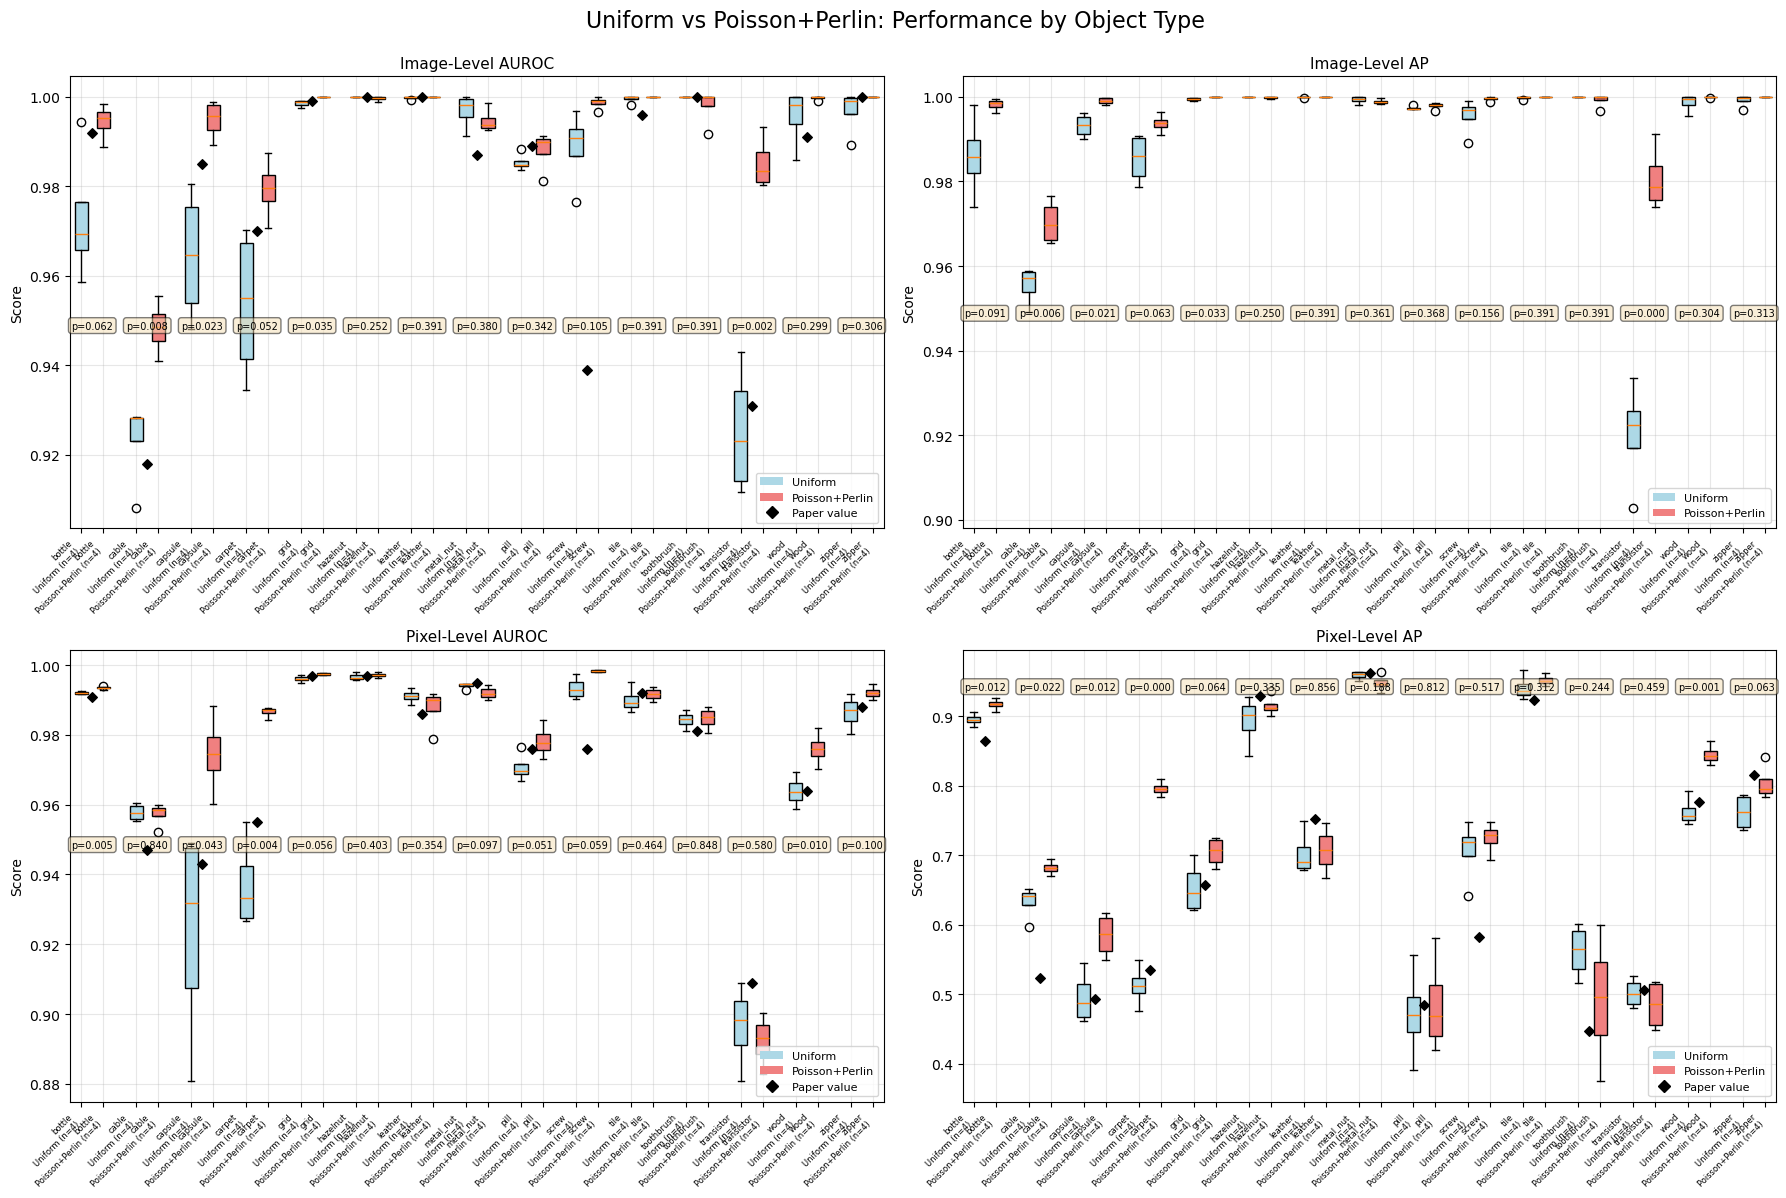


Comparison complete for 15 objects across 4 metrics


In [26]:
# Compare Uniform vs Poisson+Perlin across all objects and all metrics
uniform_method = 'uniform_beta'
poisson_perlin_method = 'poisson,perlin_beta'

# Filter data for these two methods
df_comparison = df_clean[df_clean['blend_method'].isin([uniform_method, poisson_perlin_method])]

if len(df_comparison) == 0:
    print(f"No data found for methods: {uniform_method} or {poisson_perlin_method}")
else:
    # Get list of all objects present in the filtered data
    all_objects = sorted(df_comparison['obj_name'].unique())
    
    # Create visualization by object (similar to amp_analysis.ipynb)
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Uniform vs Poisson+Perlin: Performance by Object Type', fontsize=16, y=0.995)
    
    for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
        ax = axes[idx // 2, idx % 2]
        
        # Prepare data for grouped box plot
        positions = []
        data_plot = []
        labels = []
        colors = []
        obj_center_pos = {}
        
        pos = 0
        for obj_name in all_objects:
            df_obj = df_comparison[df_comparison['obj_name'] == obj_name]
            
            if metric in df_obj.columns:
                positions_this_obj = []
                
                uniform_vals = df_obj[df_obj['blend_method'] == uniform_method][metric].dropna()
                poisson_perlin_vals = df_obj[df_obj['blend_method'] == poisson_perlin_method][metric].dropna()
                
                if len(uniform_vals) > 0:
                    positions.append(pos)
                    positions_this_obj.append(pos)
                    data_plot.append(uniform_vals)
                    labels.append(f'{obj_name}\nUniform (n={len(uniform_vals)})')
                    colors.append('lightblue')
                    pos += 1
                
                if len(poisson_perlin_vals) > 0:
                    positions.append(pos)
                    positions_this_obj.append(pos)
                    data_plot.append(poisson_perlin_vals)
                    labels.append(f'{obj_name}\nPoisson+Perlin (n={len(poisson_perlin_vals)})')
                    colors.append('lightcoral')
                    pos += 1
                
                # Calculate and display p-value for this object
                if len(uniform_vals) > 0 and len(poisson_perlin_vals) > 0:
                    _, p_val = stats.ttest_ind(uniform_vals, poisson_perlin_vals, equal_var=False, nan_policy='omit')
                    
                    # Add p-value text to the plot (center between boxes for this object)
                    if len(positions_this_obj) >= 2:
                        text_pos = (positions_this_obj[0] + positions_this_obj[-1]) / 2
                        y_pos = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.0
                        ax.text(text_pos, y_pos * 0.95, f'p={p_val:.3f}', 
                               ha='center', va='top', fontsize=7, 
                               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
                
                # Track center x-position for baseline marker overlay
                if len(positions_this_obj) > 0:
                    obj_center_pos[obj_name] = sum(positions_this_obj) / len(positions_this_obj)
                
                pos += 0.5  # Add spacing between objects
        
        # Create box plot
        if len(data_plot) > 0:
            bp = ax.boxplot(data_plot, positions=positions, widths=0.6, patch_artist=True)
            
            # Color the boxes
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
            
            # Overlay baseline markers (if available for this metric)
            if metric in baseline_df.columns:
                for _, row in baseline_df.iterrows():
                    obj = row['obj_name']
                    val = row.get(metric, None)
                    if obj in obj_center_pos and val is not None and pd.notna(val):
                        ax.scatter(obj_center_pos[obj], val, marker='D', c='black', s=24, zorder=3)
            
            ax.set_xticks(positions)
            ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=6)
            ax.set_ylabel('Score', fontsize=10)
            ax.set_title(title, fontsize=11)
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add legend
            from matplotlib.patches import Patch
            from matplotlib.lines import Line2D
            legend_elements = [Patch(facecolor='lightblue', label='Uniform'),
                              Patch(facecolor='lightcoral', label='Poisson+Perlin')]
            if metric in baseline_df.columns:
                legend_elements.append(Line2D([0], [0], marker='D', color='black', label='Paper value', markersize=6, linewidth=0))
            ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
    
    plt.tight_layout()
    fig.savefig('report/figures/uniform_vs_poisson_perlin_all_metrics.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nComparison complete for {len(all_objects)} objects across {len(metrics)} metrics")

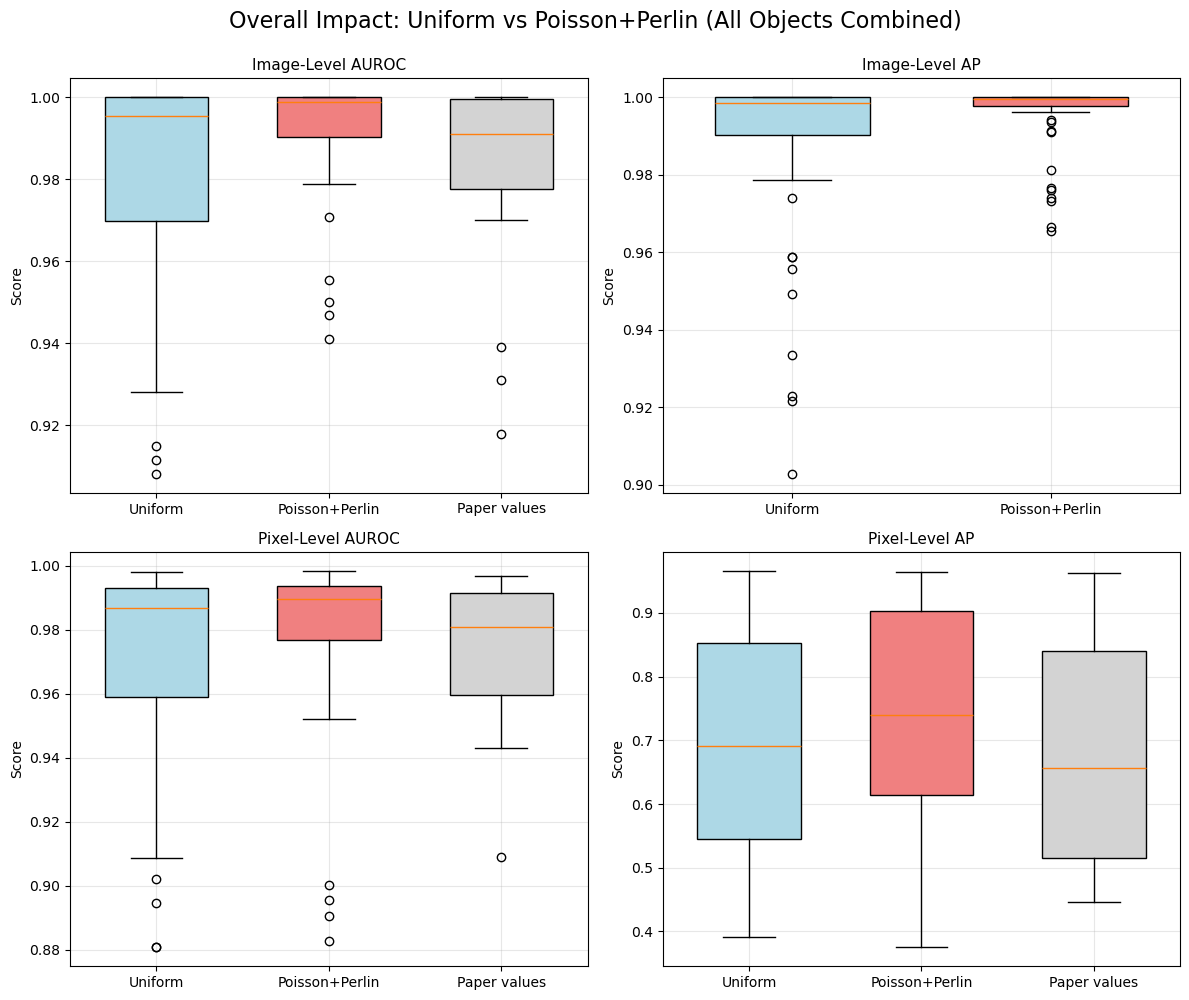


OVERALL STATISTICS (All Objects Combined)


In [28]:
# Overall comparison plot (all objects combined)
if len(df_comparison) > 0:
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
    fig2.suptitle('Overall Impact: Uniform vs Poisson+Perlin (All Objects Combined)', fontsize=16, y=0.995)
    
    for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
        if metric in df_comparison.columns:
            ax = axes2[idx // 2, idx % 2]
            
            uniform_vals = df_comparison[df_comparison['blend_method'] == uniform_method][metric].dropna()
            poisson_perlin_vals = df_comparison[df_comparison['blend_method'] == poisson_perlin_method][metric].dropna()
            
            # Baseline distribution for this metric (across objects), if available
            baseline_vals = None
            if metric in baseline_df.columns:
                baseline_vals = baseline_df[metric].dropna()
            
            data_plot = [uniform_vals, poisson_perlin_vals] + ([baseline_vals] if baseline_vals is not None and len(baseline_vals) > 0 else [])
            labels = ['Uniform', 'Poisson+Perlin'] + (['Paper values'] if baseline_vals is not None and len(baseline_vals) > 0 else [])
            
            bp = ax.boxplot(data_plot, labels=labels, patch_artist=True, widths=0.6)
            colors2 = ['lightblue', 'lightcoral'] + (['lightgray'] if baseline_vals is not None and len(baseline_vals) > 0 else [])
            for patch, color in zip(bp['boxes'], colors2):
                patch.set_facecolor(color)
            
            ax.set_ylabel('Score', fontsize=10)
            ax.set_title(title, fontsize=11)
            ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    fig2.savefig('report/figures/uniform_vs_poisson_perlin_overall.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print overall statistics
    print("\n" + "="*80)
    print("OVERALL STATISTICS (All Objects Combined)")
    print("="*80)
    for metric, title in zip(metrics, metric_titles):
        if metric in df_comparison.columns:
            uniform_vals = df_comparison[df_comparison['blend_method'] == uniform_method][metric].dropna()
            poisson_perlin_vals = df_comparison[df_comparison['blend_method'] == poisson_perlin_method][metric].dropna()
            